# NHANES 2017–2018 Multivariate Analysis

## LOADING LIBRARIES

In [ ]:
!pip install factor_analyzer

In [ ]:
!pip install pingouin

In [ ]:
!apt-get update -y
!apt-get install -y r-base

In [ ]:
!pip install rpy2

In [ ]:
!R -e "install.packages('lavaan', repos='https://cran.rstudio.com/')"

In [ ]:
!R -e "install.packages('lavaan', repos='https://cloud.r-project.org/')"

In [ ]:
!R -e "install.packages('psych', repos='https://cloud.r-project.org/')"

In [ ]:
!R -e "install.packages('corrplot', repos='https://cloud.r-project.org/')"

In [ ]:
!R -e "install.packages('semPlot', repos='https://cloud.r-project.org/')"

In [ ]:
%load_ext rpy2.ipython

In [ ]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import pingouin as pg
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from imblearn.over_sampling import SMOTE
from sklearn.cross_decomposition import CCA


In [ ]:
%%R
library(lavaan)
library(semPlot)
library(psych)
library(corrplot)

In [ ]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

## DATA PREPROCESSING

###  DATA INTEGRATION

This section focuses on preparing the raw NHANES datasets for analysis. Since the data is spread across multiple files covering areas such as demographics,
body measurements, laboratory results, lifestyle behaviors, and medical conditions, the first step is to load all .XPT files into Python. Each dataset is then examined to understand its size and to confirm that the primary key (SEQN) uniquely identifies individuals.

Next, the datasets are combined into a single dataset using SEQN as the linking variable. An inner join is applied so that only individuals with complete information across all datasets are retained. The final dataset is then explored by checking the number of observations and variables, and by classifying variables as numerical or categorical. A preview of the data is also generated, and the dataset is saved for future use.

Overall, this step ensures that the data is organized, consistent, and ready for further analysis.

In [ ]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

demo = pd.read_sas("DEMO_J.xpt")      # Demographics
bmx  = pd.read_sas("BMX_J.xpt")       # Body Measurements
bpx  = pd.read_sas("BPX_J.xpt")       # Blood Pressure
bio  = pd.read_sas("BIOPRO_J.xpt")    # Laboratory Data
hdl  = pd.read_sas("HDL_J.xpt")       # HDL Cholesterol
smq  = pd.read_sas("SMQ_J.xpt")       # Smoking Behavior
alq  = pd.read_sas("ALQ_J.xpt")       # Alcohol Consumption
mcq  = pd.read_sas("MCQ_J.xpt")       # Medical Conditions

print("\n================ DATASET SHAPES ================\n")

datasets = {
    "DEMO": demo,
    "BMX": bmx,
    "BPX": bpx,
    "BIOPRO": bio,
    "HDL": hdl,
    "SMQ": smq,
    "ALQ": alq,
    "MCQ": mcq
}

for name, data in datasets.items():
    print(f"{name}: Rows = {data.shape[0]}, Columns = {data.shape[1]}")

print("\n================================================\n")

print("\nChecking SEQN uniqueness...\n")

for name, data in datasets.items():
    unique_ids = data["SEQN"].nunique()
    total_ids = data.shape[0]
    print(f"{name}: Unique SEQN = {unique_ids}, Total Rows = {total_ids}")

print("\nNOTE: SEQN should ideally be unique per dataset.\n")

print("\nMerging datasets using INNER JOIN...\n")

df = demo.merge(bmx, on="SEQN", how="inner") \
         .merge(bpx, on="SEQN", how="inner") \
         .merge(bio, on="SEQN", how="inner") \
         .merge(hdl, on="SEQN", how="inner") \
         .merge(smq, on="SEQN", how="inner") \
         .merge(alq, on="SEQN", how="inner") \
         .merge(mcq, on="SEQN", how="inner")

print("\n================ FINAL DATASET ================\n")

n_rows, n_cols = df.shape

print(f"Final Number of Observations (n): {n_rows}")
print(f"Final Number of Variables (p): {n_cols}")

print("\n================================================\n")

print("\nClassifying variable types...\n")

numerical_vars = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_vars = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Number of Numerical Variables: {len(numerical_vars)}")
print(f"Number of Categorical Variables: {len(categorical_vars)}")

print("\nSample Numerical Variables:\n", numerical_vars[:10])
print("\nSample Categorical Variables:\n", categorical_vars[:10])

print("\nPreview of merged dataset:\n")
print(df.head())

df.to_csv("nhanes_merged.csv", index=False)

print("\nMerged dataset saved as 'nhanes_merged.csv'\n")


================ DATASET SHAPES ================

DEMO: Rows = 15560, Columns = 29
BMX: Rows = 14300, Columns = 22
BPX: Rows = 11656, Columns = 12
BIOPRO: Rows = 10409, Columns = 41
HDL: Rows = 12198, Columns = 3
SMQ: Rows = 11137, Columns = 16
ALQ: Rows = 8965, Columns = 10
MCQ: Rows = 14986, Columns = 63



Checking SEQN uniqueness...

DEMO: Unique SEQN = 15560, Total Rows = 15560
BMX: Unique SEQN = 14300, Total Rows = 14300
BPX: Unique SEQN = 11656, Total Rows = 11656
BIOPRO: Unique SEQN = 10409, Total Rows = 10409
HDL: Unique SEQN = 12198, Total Rows = 12198
SMQ: Unique SEQN = 11137, Total Rows = 11137
ALQ: Unique SEQN = 8965, Total Rows = 8965
MCQ: Unique SEQN = 14986, Total Rows = 14986

NOTE: SEQN should ideally be unique per dataset.


Merging datasets using INNER JOIN...


================ FINAL DATASET ================

Final Number of Observations (n): 8965
Final Number of Variables (p): 189



Classifying variable types...

Number of Numerical Variables: 188
Number of Cate



The datasets have different sizes, indicating that not all participants completed every survey or test. The smallest dataset (ALQ: 8,965) limits the size of the final merged dataset.

Each dataset contains unique `SEQN` values, confirming that it can be reliably used as the primary key for merging.

The final dataset includes **8,965 observations and 189 variables**. This reduction in sample size is expected because the inner join retains only participants with data available in all datasets. While this ensures completeness, it reduces the overall sample.


Most variables are identified as numerical, with only one detected as categorical. However, many of these numerical variables actually represent coded categories and will need to be properly treated in later analysis.


The dataset is high-dimensional and combines demographic, clinical, and behavioral information. The presence of missing values suggests that further data cleaning will be necessary.
The dataset is saved to ensure reproducibility and to avoid repeating the merging process.

### VARIABLE SELECTION

This section focuses on refining the merged dataset by selecting a smaller, meaningful set of variables for analysis. Since the original dataset contains a large number of variables (189), working with all of them would increase complexity, introduce noise, and make interpretation difficult. Therefore, a subset of variables is chosen based on their relevance to key health outcomes and their importance in multivariate analysis.

The selected variables represent different dimensions of health:


*   Demographic factors: Age (RIDAGEYR), Gender (RIAGENDR), and Income (INDFMPIR) provide background characteristics that may influence health.

*   Body measurements: BMI (BMXBMI) and Waist circumference (BMXWAIST) capture obesity-related risk.

*   Blood pressure readings: Multiple systolic (BPXOSY1–3) and diastolic (BPXODI1–3) measurements are used to compute average blood pressure, improving reliability.
*   Laboratory measures: Triglycerides (LBXSTR), Creatinine (LBXSCR), and HDL cholesterol (LBDHDD) reflect metabolic and cardiovascular health.


*   Behavioral factors: Smoking (SMQ020) and Alcohol consumption (ALQ111) capture lifestyle risks.


*   Medical condition: Heart disease status (MCQ160C) serves as an important health outcome variable.


Feature engineering is then applied by averaging repeated blood pressure measurements to obtain more stable systolic and diastolic values. Categorical variables, originally encoded numerically, are converted into meaningful labels to improve interpretability. Redundant variables are removed, key variables are renamed for clarity, and special missing value codes are handled appropriately.

Overall, this step reduces dimensionality while retaining the most relevant information, resulting in a cleaner, more interpretable dataset that is better suited for further statistical analysis.

In [ ]:
df = pd.read_csv("nhanes_merged.csv")

print("\nInitial shape:", df.shape)

selected_vars = [
    "SEQN",
    "RIDAGEYR", "RIAGENDR", "INDFMPIR",
    "BMXBMI", "BMXWAIST",
    "BPXOSY1", "BPXOSY2", "BPXOSY3",
    "BPXODI1", "BPXODI2", "BPXODI3",
    "LBXSTR", "LBXSCR", "LBDHDD",
    "SMQ020", "ALQ111",
    "MCQ160C"
]

df_selected = df[selected_vars].copy()
print("\nAfter selection:", df_selected.shape)

df_selected["SYS_BP"] = df_selected[["BPXOSY1","BPXOSY2","BPXOSY3"]].mean(axis=1)
df_selected["DIA_BP"] = df_selected[["BPXODI1","BPXODI2","BPXODI3"]].mean(axis=1)

df_selected.drop(columns=[
    "BPXOSY1","BPXOSY2","BPXOSY3",
    "BPXODI1","BPXODI2","BPXODI3"
], inplace=True)

df_selected["Gender"] = df_selected["RIAGENDR"].map({
    1: "Male",
    2: "Female"
})

df_selected["Smoking"] = df_selected["SMQ020"].map({
    1: "Yes",
    2: "No"
})

df_selected["Alcohol"] = df_selected["ALQ111"].map({
    1: "Yes",
    2: "No"
})

df_selected["Heart_Disease"] = df_selected["MCQ160C"].map({
    1: "Yes",
    2: "No"
})

df_selected.drop(columns=[
    "RIAGENDR", "SMQ020", "ALQ111", "MCQ160C"
], inplace=True)

df_selected.rename(columns={
    "RIDAGEYR": "Age",
    "INDFMPIR": "Income",
    "BMXBMI": "BMI",
    "BMXWAIST": "Waist",
    "LBXSTR": "Triglycerides",
    "LBXSCR": "Creatinine",
    "LBDHDD": "HDL"
}, inplace=True)

df_selected.replace({7: np.nan, 9: np.nan}, inplace=True)

print("\nFinal dataset shape:", df_selected.shape)
print("\nColumns:\n", df_selected.columns.tolist())

print("\nPreview:\n")
print(df_selected.head())

df_selected.to_csv("nhanes_selected.csv", index=False)

print("\nSaved as nhanes_selected.csv")


Initial shape: (8965, 189)

After selection: (8965, 18)

Final dataset shape: (8965, 14)

Columns:
 ['SEQN', 'Age', 'Income', 'BMI', 'Waist', 'Triglycerides', 'Creatinine', 'HDL', 'SYS_BP', 'DIA_BP', 'Gender', 'Smoking', 'Alcohol', 'Heart_Disease']

Preview:

       SEQN   Age  Income   BMI  Waist  Triglycerides  Creatinine   HDL      SYS_BP     DIA_BP  Gender Smoking Alcohol Heart_Disease
0  109266.0  29.0    5.00  37.8  117.9           86.0        0.63  56.0   99.000000  54.333333  Female      No     Yes            No
1  109271.0  49.0     NaN  29.7  120.4          101.0        0.78  33.0  107.000000  67.000000    Male     Yes     Yes            No
2  109273.0  36.0    0.83  21.9   86.8          178.0        0.92  42.0  113.666667  67.333333    Male     Yes     Yes            No
3  109274.0  68.0    1.20  30.2  109.6          151.0        0.74  29.0  134.000000  70.000000    Male      No     Yes            No
4  109282.0  76.0    3.61  26.6    NaN          151.0        0.88  43.0  1

### MISSING VALUE ANALYSIS & IMPUTATION

This section focuses on identifying and handling missing values to ensure the dataset is suitable for reliable analysis. First, the extent of missing data is examined using both summary statistics and a visual heatmap, providing an overview of how missing values are distributed across variables.

Since the target variable (Heart Disease) is essential for analysis, rows with missing values in this variable are removed to avoid ambiguity in model outcomes. The remaining variables are then categorized into numerical and categorical types.

To address missing values, appropriate imputation methods are applied:



*   Numerical variables are imputed using the median, which is robust to outliers.
*   Categorical variables are imputed using the mode, representing the most frequent category.





Finally, the dataset is rechecked to confirm that all missing values have been handled, and the cleaned dataset is saved for further analysis.


Initial dataset shape: (8965, 14)

================ MISSING VALUE SUMMARY ================

               Missing_Count  Missing_Percent
Income                  1260        14.054657
DIA_BP                   941        10.496375
SYS_BP                   941        10.496375
Triglycerides            710         7.919688
Creatinine               708         7.897379
HDL                      667         7.440045
Alcohol                  595         6.636921
Waist                    516         5.755717
Heart_Disease            447         4.986057
BMI                      175         1.952036
Smoking                    4         0.044618
Age                        0         0.000000
SEQN                       0         0.000000
Gender                     0         0.000000


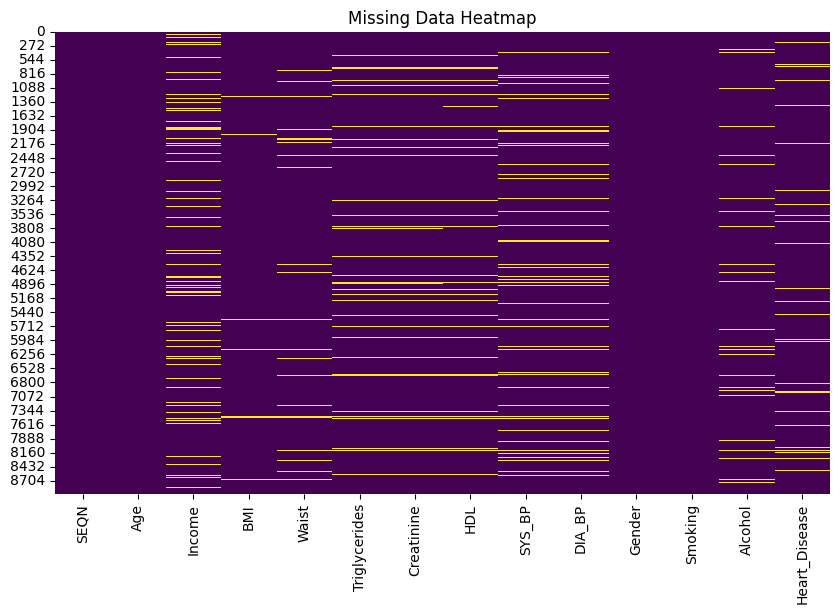


Removing rows with missing Heart_Disease...

Shape after removing missing target: (8518, 14)

Numerical variables:
 ['Age', 'Income', 'BMI', 'Waist', 'Triglycerides', 'Creatinine', 'HDL', 'SYS_BP', 'DIA_BP']

Categorical variables:
 ['Gender', 'Smoking', 'Alcohol', 'Heart_Disease']

Imputing numerical variables with MEDIAN...

Age → median = 52.0
Income → median = 2.2
BMI → median = 28.8
Waist → median = 99.4
Triglycerides → median = 113.0
Creatinine → median = 0.84
HDL → median = 51.0
SYS_BP → median = 122.0
DIA_BP → median = 74.0

Imputing categorical variables with MODE...

Gender → mode = Female
Smoking → mode = No
Alcohol → mode = Yes
Heart_Disease → mode = No

================ FINAL MISSING CHECK ================

SEQN             0
Age              0
Income           0
BMI              0
Waist            0
Triglycerides    0
Creatinine       0
HDL              0
SYS_BP           0
DIA_BP           0
Gender           0
Smoking          0
Alcohol          0
Heart_Disease    0
dty

In [ ]:
pd.set_option('display.max_columns', 100)

df = pd.read_csv("nhanes_selected.csv")
print("\nInitial dataset shape:", df.shape)

print("\n================ MISSING VALUE SUMMARY ================\n")

missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent": missing_percent
}).sort_values(by="Missing_Percent", ascending=False)

print(missing_summary)

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

print("\nRemoving rows with missing Heart_Disease...\n")
df = df.dropna(subset=["Heart_Disease"]).copy()
print("Shape after removing missing target:", df.shape)

categorical_vars = ["Gender", "Smoking", "Alcohol", "Heart_Disease"]

numerical_vars = [
    col for col in df.columns
    if col not in categorical_vars + ["SEQN"]
]

print("\nNumerical variables:\n", numerical_vars)
print("\nCategorical variables:\n", categorical_vars)

print("\nImputing numerical variables with MEDIAN...\n")

for col in numerical_vars:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col} → median = {median_value}")

print("\nImputing categorical variables with MODE...\n")

for col in categorical_vars:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"{col} → mode = {mode_value}")

print("\n================ FINAL MISSING CHECK ================\n")
print(df.isnull().sum())

print("\nFinal dataset shape:", df.shape)
print("\nPreview:\n")
print(df.head())

df.to_csv("nhanes_cleaned.csv", index=False)
print("\nClean dataset saved as 'nhanes_cleaned.csv'")

The dataset initially contains 8,965 observations and 14 variables. Missing values are present across several variables, with Income (14.05%), blood pressure (≈10.5%), and laboratory measures (~7–8%) showing the highest proportions of missingness. This suggests that some variables were not recorded for all participants, which is common in survey-based health data.

The heatmap visually confirms that missing values are spread across multiple variables rather than concentrated in a single area, indicating a need for systematic handling.


Rows with missing values in Heart_Disease were removed, reducing the dataset to 8,518 observations. This step ensures that the outcome variable is fully observed, which is crucial for any supervised analysis.



*   Numerical variables were imputed using median values (e.g., Age = 52, BMI = 28.8, SYS_BP = 122), providing stable central estimates without being influenced by extreme values.
*   Categorical variables were imputed using the most frequent category (e.g., Gender = Female, Smoking = No, Alcohol = Yes, Heart Disease = No), preserving the dominant patterns in the data.





After imputation, all variables have zero missing values, resulting in a complete dataset. The final dataset retains 8,518 observations and 14 variables, making it clean, consistent, and suitable for further statistical analysis.

This step effectively addresses missing data through a combination of removal and imputation, ensuring data completeness while maintaining the integrity of the dataset.

### OUTLIER DETECTION & DATA TRANSFORMATION

This section focuses on identifying and handling outliers, while also preparing the data for further analysis. First, numerical variables are explored using boxplots to visually identify extreme values and understand how each variable is distributed.

To support this, the Z-score method is used to detect outliers quantitatively, where values beyond a certain threshold (|z| > 3) are flagged as potential outliers. Instead of removing these values, transformations are applied to reduce the effect of skewness in variables such as income and triglycerides.

Finally, all numerical variables are standardized so that they are on a common scale (mean close to 0 and standard deviation close to 1). This is important for many statistical techniques, as it ensures that no single variable dominates due to differences in scale.


Dataset shape: (8518, 14)

Numerical variables:
 ['Age', 'Income', 'BMI', 'Waist', 'Triglycerides', 'Creatinine', 'HDL', 'SYS_BP', 'DIA_BP']

Generating boxplots...



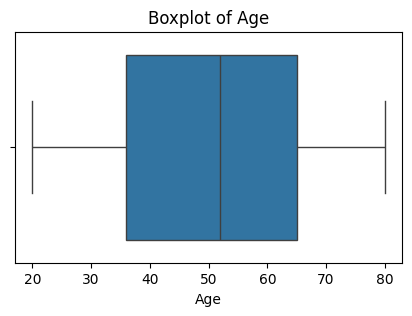

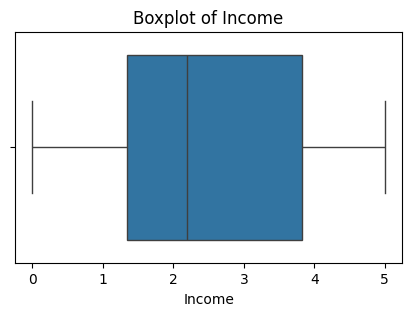

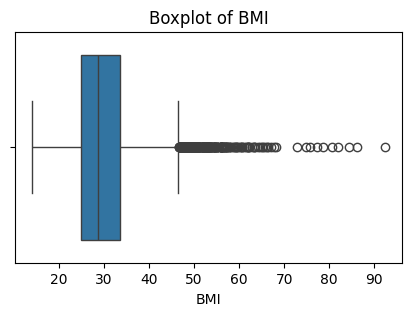

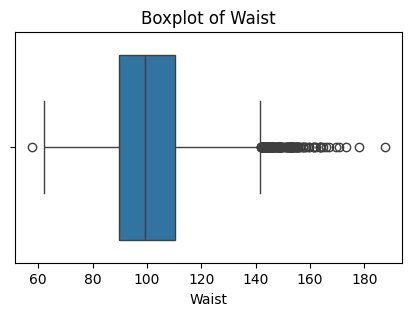

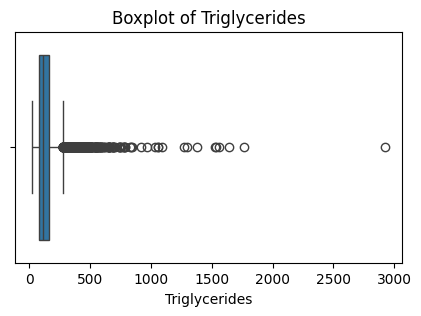

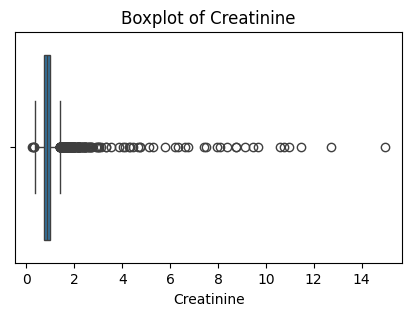

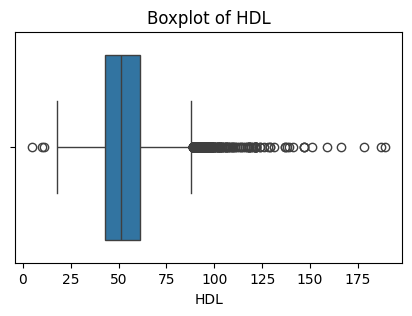

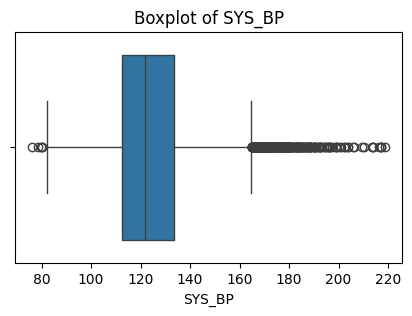

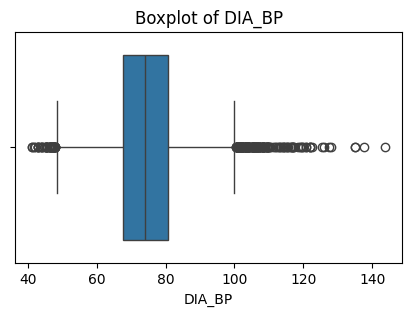


================ Z-SCORE OUTLIER DETECTION ================

        Variable  Outlier_Count
0            Age              0
1         Income              0
2            BMI            112
3          Waist             61
4  Triglycerides            123
5     Creatinine             55
6            HDL             90
7         SYS_BP             95
8         DIA_BP             65

Applying log transformation...

Income transformed using log(x+1)
Triglycerides transformed using log(x+1)

Applying standardization...


Standardization complete.

Preview of final dataset:

       SEQN       Age    Income       BMI     Waist  Triglycerides  Creatinine       HDL    SYS_BP    DIA_BP  Gender Smoking Alcohol Heart_Disease
0  109266.0 -1.251870  1.377004  1.038978  1.023445      -0.582559   -0.539877  0.169024 -1.389705 -1.844712  Female      No     Yes            No
1  109271.0 -0.110920 -0.003260 -0.041680  1.173766      -0.279537   -0.244125 -1.324021 -0.954709 -0.694647    Male     Yes     Ye

In [ ]:
pd.set_option('display.max_columns', 100)

df = pd.read_csv("nhanes_cleaned.csv")
print("\nDataset shape:", df.shape)

categorical_vars = ["Gender", "Smoking", "Alcohol", "Heart_Disease"]

numerical_vars = [
    col for col in df.columns
    if col not in categorical_vars + ["SEQN"]
]

print("\nNumerical variables:\n", numerical_vars)

print("\nGenerating boxplots...\n")

for col in numerical_vars:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

print("\n================ Z-SCORE OUTLIER DETECTION ================\n")

z_scores = np.abs(zscore(df[numerical_vars]))

outlier_counts = (z_scores > 3).sum(axis=0)

outlier_summary = pd.DataFrame({
    "Variable": numerical_vars,
    "Outlier_Count": outlier_counts
})

print(outlier_summary)

outlier_summary.to_csv("outlier_summary.csv", index=False)

print("\nApplying log transformation...\n")

skewed_vars = ["Income", "Triglycerides"]

for col in skewed_vars:
    if col in df.columns:
        df[col] = np.log1p(df[col])
        print(f"{col} transformed using log(x+1)")

numerical_vars = [
    col for col in df.columns
    if col not in categorical_vars + ["SEQN"]
]

print("\nApplying standardization...\n")

scaler = StandardScaler()

df_final = df.copy()

df_final[numerical_vars] = scaler.fit_transform(df[numerical_vars])

print("\nStandardization complete.")

print("\nPreview of final dataset:\n")
print(df_final.head())

print("\nSummary statistics (mean ≈ 0, std ≈ 1 expected):\n")
print(df_final[numerical_vars].describe())

df_final.to_csv("nhanes_final.csv", index=False)

print("\nFinal dataset saved as 'nhanes_final.csv'")

The boxplots show that several variables, especially BMI, Triglycerides, HDL, and Blood Pressure, have noticeable outliers, mostly on the higher end. In contrast, variables like Age and Income appear more evenly distributed with fewer extreme values.



The outlier counts support these observations:

*   Triglycerides (123) and BMI (112) have the highest number of outliers.

*   Blood pressure variables (SYS_BP: 95, DIA_BP: 65) and HDL (90) also show a considerable number of outliers.
*   Age and Income do not show extreme outliers under the Z-score criterion.


This suggests that clinical measurements tend to have more variability and extreme values compared to demographic variables.


Log transformation was applied to Income and Triglycerides, which helps reduce skewness and limit the influence of extreme values, making their distributions more balanced.


After scaling, all numerical variables have means close to 0 and standard deviations close to 1, confirming that standardization was successful. This ensures that all variables contribute equally in later analyses.


The dataset remains with 8,518 observations and 14 variables, but is now better conditioned for analysis.


Overall, this step improves the quality of the data by addressing outliers, reducing skewness, and standardizing variables, making the dataset more suitable for multivariate analysis.

## EXPLORATORY DATA ANALYSIS (EDA)

This section explores the cleaned and transformed dataset to better understand the patterns and relationships within the data. It begins with summary statistics to describe the central tendency, variability, and overall distribution of each numerical variable, including measures such as skewness and kurtosis.

Next, visualizations are used to gain deeper insights. Histograms help examine how variables are distributed, while scatter plots highlight relationships between key variables. A correlation matrix and heatmap are then used to clearly show the strength and direction of relationships across variables.

Pairwise plots are also included to provide a more detailed view of how variables interact with each other.

Overall, this step helps build a clear understanding of the data, identify important patterns, and confirm that the dataset is well-prepared for further analysis.


Dataset shape: (8518, 14)

Numerical variables:
 ['Age', 'Income', 'BMI', 'Waist', 'Triglycerides', 'Creatinine', 'HDL', 'SYS_BP', 'DIA_BP']

================ SUMMARY STATISTICS ================

                count          mean       std       min       25%       50%       75%        max   Skewness    Kurtosis
Age            8518.0  4.421081e-17  1.000059 -1.765297 -0.852538  0.060222  0.801839   1.657551  -0.031125   -1.114699
Income         8518.0  3.820481e-16  1.000059 -2.557242 -0.690528 -0.003260  0.896167   1.377004  -0.306060   -0.589800
BMI            8518.0 -1.209541e-16  1.000059 -2.109605 -0.668728 -0.161753  0.478637   8.310069   1.377800    4.054949
Waist          8518.0  1.274189e-16  1.000059 -2.584260 -0.672176 -0.088930  0.578495   5.208383   0.559871    0.571026
Triglycerides  8518.0 -4.796455e-16  1.000059 -2.883467 -0.672223 -0.067649  0.578106   6.113214   0.579905    1.001294
Creatinine     8518.0  1.117783e-16  1.000059 -1.289117 -0.362426 -0.125824  0.1699

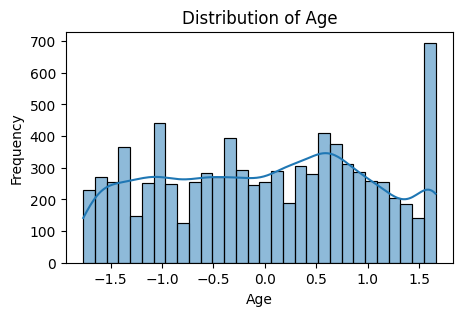

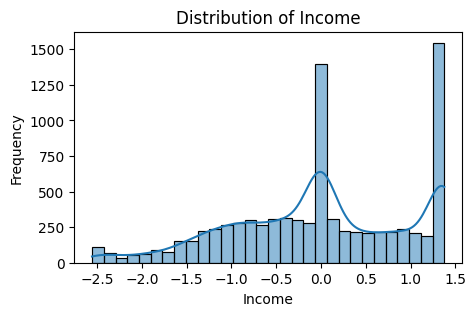

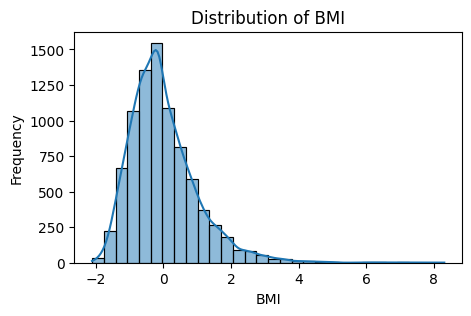

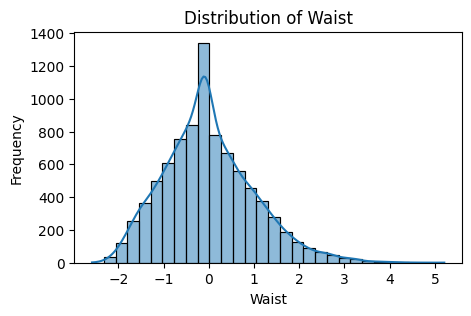

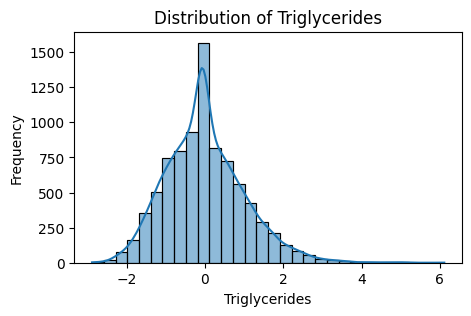

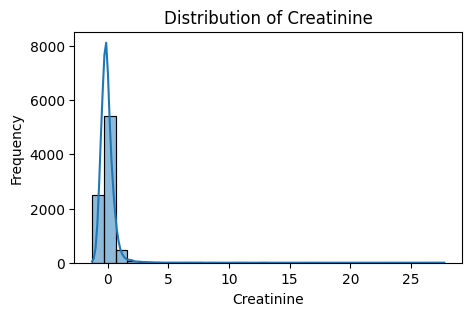

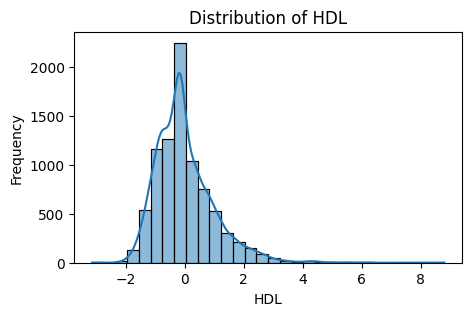

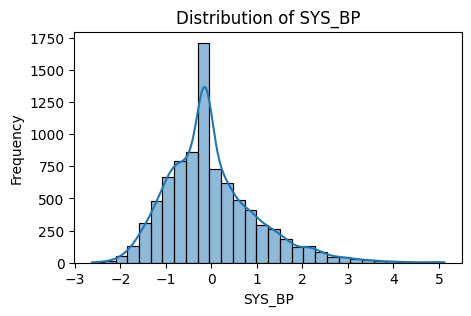

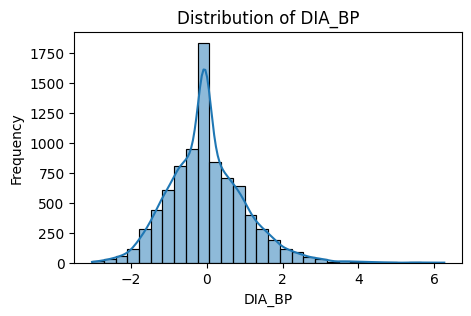


================ CORRELATION MATRIX ================

                Age  Income   BMI  Waist  Triglycerides  Creatinine   HDL  SYS_BP  DIA_BP
Age            1.00    0.07 -0.00   0.15           0.13        0.15  0.07    0.41    0.01
Income         0.07    1.00 -0.04  -0.02          -0.00       -0.00  0.08   -0.03   -0.02
BMI           -0.00   -0.04  1.00   0.86           0.18        0.01 -0.26    0.02    0.19
Waist          0.15   -0.02  0.86   1.00           0.26        0.06 -0.31    0.10    0.21
Triglycerides  0.13   -0.00  0.18   0.26           1.00        0.04 -0.45    0.10    0.13
Creatinine     0.15   -0.00  0.01   0.06           0.04        1.00 -0.07    0.12    0.01
HDL            0.07    0.08 -0.26  -0.31          -0.45       -0.07  1.00    0.02   -0.06
SYS_BP         0.41   -0.03  0.02   0.10           0.10        0.12  0.02    1.00    0.61
DIA_BP         0.01   -0.02  0.19   0.21           0.13        0.01 -0.06    0.61    1.00


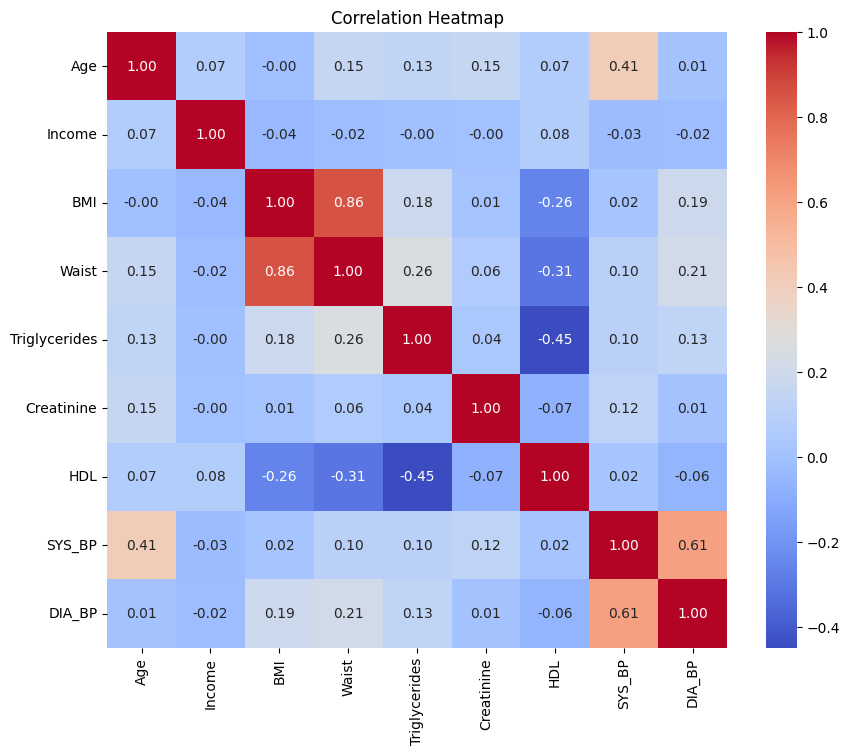


Generating key relationship plots...



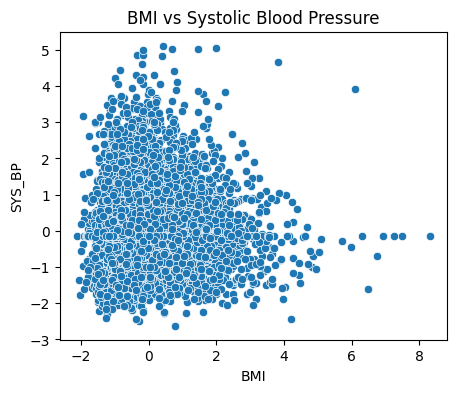

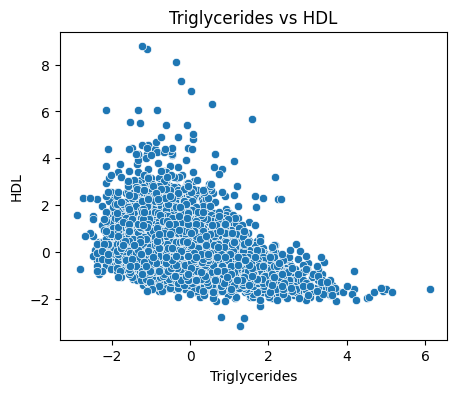

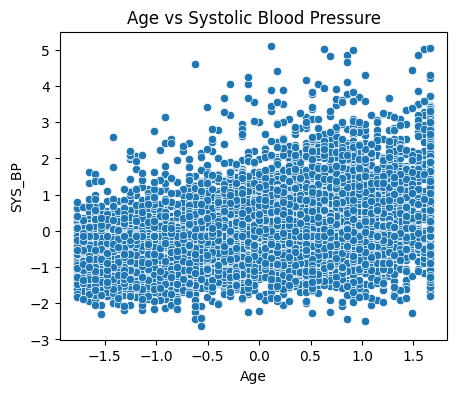


Generating pairplot (may take time)...



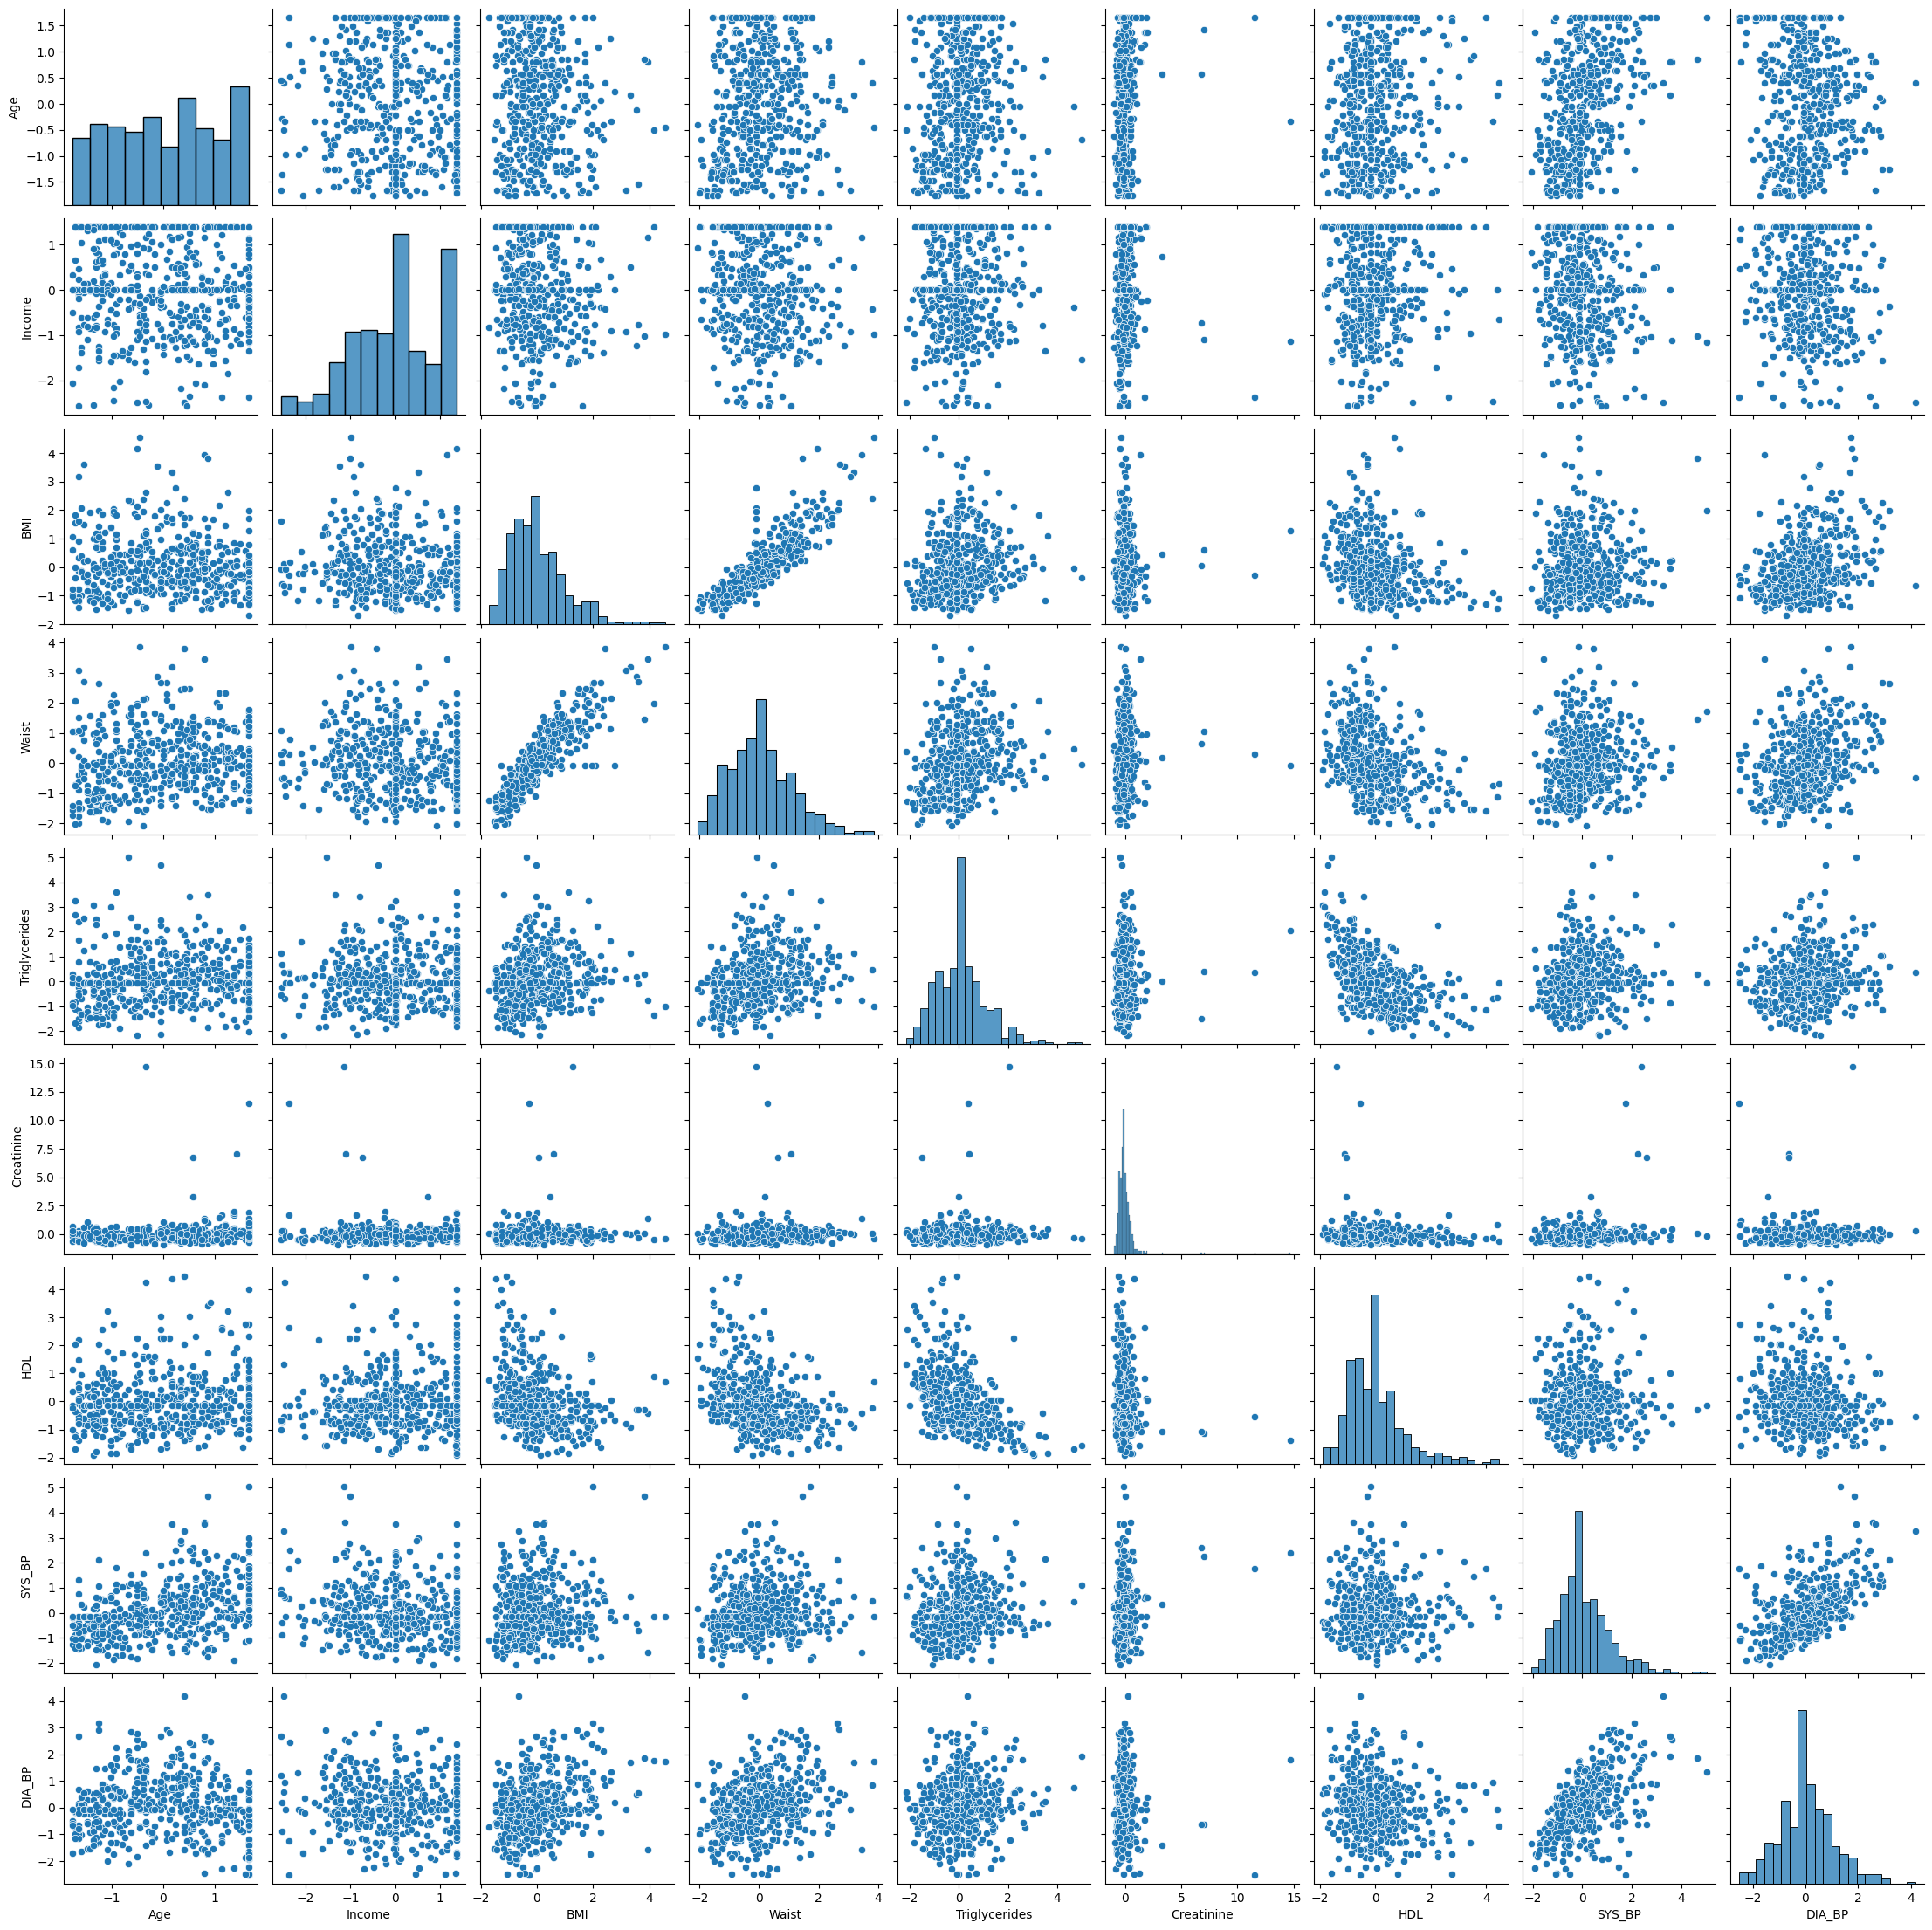

In [ ]:

pd.set_option('display.max_columns', 100)

df = pd.read_csv("nhanes_final.csv")

print("\nDataset shape:", df.shape)

# IDENTIFY VARIABLE TYPES
categorical_vars = ["Gender", "Smoking", "Alcohol", "Heart_Disease"]

numerical_vars = [
    col for col in df.columns
    if col not in categorical_vars + ["SEQN"]
]

print("\nNumerical variables:\n", numerical_vars)

# SUMMARY STATISTICS
print("\n================ SUMMARY STATISTICS ================\n")

summary_stats = df[numerical_vars].describe().T

# Add skewness & kurtosis
summary_stats["Skewness"] = df[numerical_vars].skew()
summary_stats["Kurtosis"] = df[numerical_vars].kurtosis()

print(summary_stats)

# Save summary
summary_stats.to_csv("summary_statistics.csv")

# DISTRIBUTION PLOTS (HISTOGRAMS)
print("\nGenerating histograms...\n")

for col in numerical_vars:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# CORRELATION MATRIX
print("\n================ CORRELATION MATRIX ================\n")

corr_matrix = df[numerical_vars].corr()

print(corr_matrix.round(2))

# Save correlation matrix
corr_matrix.to_csv("correlation_matrix.csv")

# HEATMAP (VERY IMPORTANT)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# KEY RELATIONSHIP PLOTS
print("\nGenerating key relationship plots...\n")

# BMI vs Blood Pressure
plt.figure(figsize=(5,4))
sns.scatterplot(x=df["BMI"], y=df["SYS_BP"])
plt.title("BMI vs Systolic Blood Pressure")
plt.show()

# Triglycerides vs HDL
plt.figure(figsize=(5,4))
sns.scatterplot(x=df["Triglycerides"], y=df["HDL"])
plt.title("Triglycerides vs HDL")
plt.show()

# Age vs Blood Pressure
plt.figure(figsize=(5,4))
sns.scatterplot(x=df["Age"], y=df["SYS_BP"])
plt.title("Age vs Systolic Blood Pressure")
plt.show()

# PAIRPLOT (HIGH VALUE)

print("\nGenerating pairplot (may take time)...\n")

sns.pairplot(df[numerical_vars].sample(500))
plt.show()

After transformation and standardization, most variables follow an approximately normal distribution, especially Age, SYS_BP, DIA_BP, Waist, and Triglycerides. However, some variables still show noticeable skewness:


*   BMI and HDL are slightly right-skewed, with a few higher extreme values.
*   Creatinine shows strong positive skewness with clear outliers, indicating the presence of unusually high values.

This suggests that although transformations improved the distributions, some clinical variables naturally remain more variable.




*   Age and Systolic Blood Pressure:
There is a moderate positive relationship (correlation ≈ 0.41), indicating that systolic blood pressure tends to increase with age.

*   BMI and Systolic Blood Pressure:
The relationship is relatively weak and scattered, suggesting that BMI alone does not strongly explain variations in systolic blood pressure.
*   Triglycerides and HDL:
A moderate negative relationship (≈ −0.45) is observed, meaning higher triglyceride levels are associated with lower HDL levels.


Several Correlation patterns can be observed:

Strong Positive Relationships:

*   BMI and Waist (0.86): Both measure similar aspects of body fat.
*   SYS_BP and DIA_BP (0.61): Expected, as both represent blood pressure.


Moderate Relationships:

*   Age and SYS_BP (0.41): Age appears to be an important factor influencing systolic blood pressure.
*   Waist and Triglycerides (0.26): Suggests a link between abdominal fat and lipid levels.




Negative Relationships:

*   Triglycerides and HDL (−0.45): A meaningful inverse relationship.
*   BMI and HDL (−0.26), Waist and HDL (−0.31): Higher body fat is associated with lower HDL levels.



Weak Relationships:

*   Income shows very little correlation with most variables, indicating limited direct influence on these health measures.



The pairplot supports these findings by showing:

*   Strong clustering between BMI and Waist
*   A clear inverse pattern between Triglycerides and HDL
*   A moderate upward trend between Age and Blood Pressure
*   High variability in Creatinine, with some extreme values




Overall, the analysis reveals several meaningful patterns. Age shows a clear association with blood pressure, body fat measures are closely related and linked to lipid levels, and triglycerides have an inverse relationship with HDL. While most variables behave well after transformation, some still show high variability and outliers.

These findings indicate that the dataset captures realistic health relationships and is well-prepared for further multivariate analysis.

## PRINCIPAL COMPONENT ANALYSIS (PCA)

Principal Component Analysis (PCA) is a multivariate statistical technique used to reduce the dimensionality of a dataset while retaining as much variability as possible. It transforms a set of correlated variables into a new set of uncorrelated variables, known as principal components.

Mathematically, each principal component is defined as a linear combination of the original variables:

$$
Y_k = e_{k1}X_1 + e_{k2}X_2 + \cdots + e_{kp}X_p
$$

where:

- $Y_k$ is the $k$-th principal component  
- $e_{kj}$ are the component loadings (coefficients)  
- $X_j$ are the original variables  

The first principal component captures the maximum variance in the data, while each subsequent component explains the remaining variance under the constraint of being uncorrelated with previous components.


From the full dataset, a subset of numerical variables was selected:

- Age, Income  
- BMI, Waist  
- Triglycerides, Creatinine, HDL  
- SYS_BP, DIA_BP  

The selection was guided by the following considerations:

- These variables represent key **physiological, metabolic, and demographic factors** relevant to health outcomes  
- Several of these variables are expected to be **correlated** (e.g., BMI and Waist, SYS_BP and DIA_BP), making them suitable for dimensionality reduction  
- Including only relevant numerical variables helps **reduce noise and improve interpretability**  
- Categorical variables were excluded, as PCA is designed for continuous data



PCA relies on the following key assumptions:

- Variables are measured on a continuous scale  
- Linear relationships exist among variables  
- Variables exhibit sufficient correlation  
- Data is standardized when variables are on different scales  

In this analysis, these assumptions are satisfied:

- All selected variables (e.g., BMI, blood pressure, lipid measures) are continuous health-related measurements  
- Prior exploratory analysis (correlation matrix and scatter plots) confirmed meaningful relationships among variables (e.g., BMI–Waist, SYS_BP–DIA_BP)  
- The dataset was standardized prior to PCA, ensuring comparability across variables  

Thus, the application of PCA in this context is appropriate and statistically valid.



PCA is applied to the standardized numerical variables. Since the data is standardized, the analysis is effectively based on the **correlation matrix** rather than the covariance matrix.

The procedure includes:

- Computing **eigenvalues** to measure the variance explained by each component  
- Calculating **explained variance ratios** to assess the contribution of each component  
- Using **Scree plots** (Kaiser criterion) and **cumulative variance plots** to determine the optimal number of components  
- Examining **component loadings** to interpret the meaning of each principal component  
- Computing **PCA scores** to transform the original data into the new reduced-dimensional space  



Overall, PCA is used in this study to identify underlying patterns among health-related variables and to reduce dimensionality while preserving the most important information in the dataset.


Dataset shape: (8518, 14)

Variables used for PCA:
 ['Age', 'Income', 'BMI', 'Waist', 'Triglycerides', 'Creatinine', 'HDL', 'SYS_BP', 'DIA_BP']

================ PCA RESULTS ================

Eigenvalues:
 [2.37782362 1.64854904 1.15232877 1.10267086 0.98877101 0.8580362
 0.5025041  0.24530025 0.12507286]

Explained Variance Ratio:
 [0.26417161 0.18315061 0.1280215  0.1225046  0.10985055 0.09532616
 0.05582723 0.02725238 0.01389535]


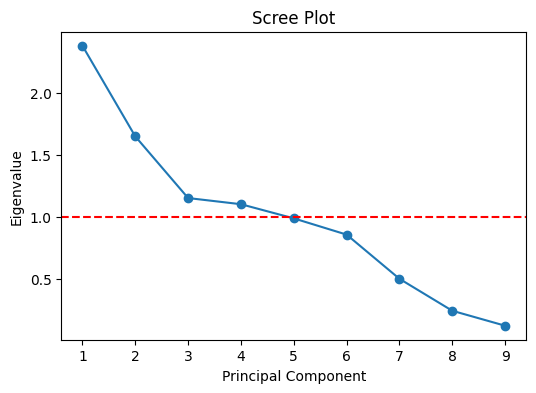

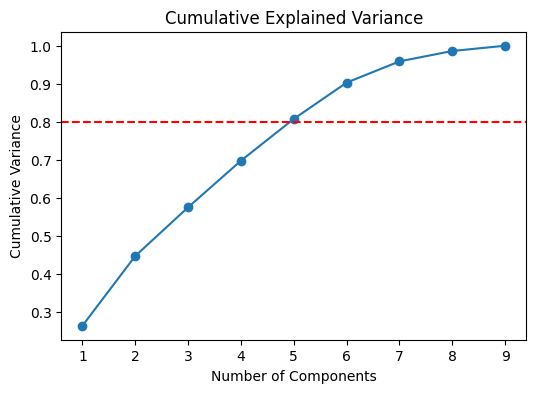


Cumulative Variance:
 [0.26417161 0.44732222 0.57534372 0.69784832 0.80769887 0.90302503
 0.95885226 0.98610465 1.        ]

================ LOADINGS ================

                 PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9
Age            0.167  0.420  0.358  0.388 -0.048 -0.565 -0.172 -0.382 -0.142
Income        -0.044  0.067  0.138  0.470  0.779  0.373 -0.075  0.047 -0.006
BMI            0.498 -0.287 -0.298  0.302 -0.089  0.012  0.072  0.143 -0.676
Waist          0.545 -0.211 -0.174  0.319 -0.077 -0.058  0.012 -0.009  0.719
Triglycerides  0.349 -0.089  0.465 -0.342  0.291 -0.173  0.645  0.080 -0.019
Creatinine     0.101  0.161  0.480  0.222 -0.514  0.631  0.144 -0.031 -0.019
HDL           -0.340  0.294 -0.368  0.383 -0.094 -0.108  0.700  0.057  0.055
SYS_BP         0.272  0.636 -0.084 -0.137  0.009 -0.015 -0.163  0.684  0.032
DIA_BP         0.323  0.409 -0.382 -0.323  0.139  0.312  0.079 -0.594 -0.042

PCA Scores Preview:

        PC1       PC2       PC3       

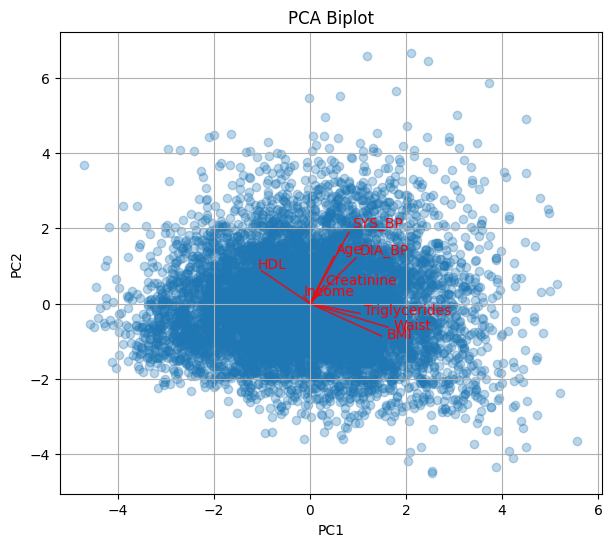

In [ ]:
pd.set_option('display.max_columns', 100)

df = pd.read_csv("nhanes_final.csv")

print("\nDataset shape:", df.shape)

categorical_vars = ["Gender", "Smoking", "Alcohol", "Heart_Disease"]

numerical_vars = [
    col for col in df.columns
    if col not in categorical_vars + ["SEQN"]
]

X = df[numerical_vars]

print("\nVariables used for PCA:\n", numerical_vars)

pca = PCA()
pca.fit(X)

eigenvalues = pca.explained_variance_
explained_variance = pca.explained_variance_ratio_

print("\n================ PCA RESULTS ================\n")

print("Eigenvalues:\n", eigenvalues)
print("\nExplained Variance Ratio:\n", explained_variance)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.axhline(y=1, color='r', linestyle='--')  # Kaiser line
plt.show()

cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.axhline(y=0.8, color='r', linestyle='--')
plt.show()

print("\nCumulative Variance:\n", cumulative_variance)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(numerical_vars))],
    index=numerical_vars
)

print("\n================ LOADINGS ================\n")
print(loadings.round(3))

loadings.to_csv("pca_loadings.csv")

scores = pca.transform(X)

scores_df = pd.DataFrame(
    scores,
    columns=[f"PC{i+1}" for i in range(len(numerical_vars))]
)

print("\nPCA Scores Preview:\n")
print(scores_df.head())

scores_df.to_csv("pca_scores.csv", index=False)

plt.figure(figsize=(7,6))

plt.scatter(scores[:,0], scores[:,1], alpha=0.3)

for i, var in enumerate(numerical_vars):
    plt.arrow(0, 0,
              loadings.iloc[i, 0]*3,
              loadings.iloc[i, 1]*3,
              color='red', alpha=0.7)
    plt.text(loadings.iloc[i, 0]*3.2,
             loadings.iloc[i, 1]*3.2,
             var, color='red')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot")
plt.grid()
plt.show()



Principal Component Analysis was applied to nine standardized numerical variables. The selection of components was based on multiple criteria:

- **Kaiser Criterion (Eigenvalue > 1):**  
  The first four components (PC1–PC4) have eigenvalues greater than 1, while PC5 is approximately equal to 1 and can be considered borderline.

- **Scree Plot:**  
  The scree plot shows a clear elbow around the 4th–5th component, indicating diminishing additional variance beyond this point.

- **Cumulative Variance:**  
  - First 4 components explain **69.8%** of total variance  
  - First 5 components explain **80.8%** of total variance  

Based on these results, **five principal components (PC1–PC5)** were retained, as they capture a substantial proportion of the total variability while maintaining interpretability.



Since the variables were standardized, each component is expressed as a linear combination of standardized variables.

Let $Z_{variable}$ denote standardized variables.



**PC1 – Metabolic Risk Component (26.4%)**

$$
PC1 = 0.167Z_{Age} - 0.044Z_{Income} + 0.498Z_{BMI} + 0.545Z_{Waist}
+ 0.349Z_{Triglycerides} + 0.101Z_{Creatinine} - 0.340Z_{HDL}
+ 0.272Z_{SYS\_BP} + 0.323Z_{DIA\_BP}
$$

PC1 is dominated by strong positive contributions from **BMI, Waist, Triglycerides, and Blood Pressure**, and a negative contribution from **HDL**. This clearly represents a **metabolic and cardiovascular risk dimension**, where individuals with higher values exhibit characteristics associated with metabolic syndrome.



**PC2 – Blood Pressure and Age Component (18.3%)**

$$
PC2 = 0.420Z_{Age} + 0.067Z_{Income} - 0.287Z_{BMI} - 0.211Z_{Waist}
- 0.089Z_{Triglycerides} + 0.161Z_{Creatinine} + 0.294Z_{HDL}
+ 0.636Z_{SYS\_BP} + 0.409Z_{DIA\_BP}
$$


PC2 is strongly associated with **SYS_BP, DIA_BP, and Age**, indicating a **blood pressure–aging relationship**. This component reflects physiological changes linked to aging and their effect on blood pressure.



**PC3 – Lipid and Renal Function Component (12.8%)**

$$
PC3 = 0.358Z_{Age} + 0.138Z_{Income} - 0.298Z_{BMI} - 0.174Z_{Waist}
+ 0.465Z_{Triglycerides} + 0.480Z_{Creatinine} - 0.368Z_{HDL}
- 0.084Z_{SYS\_BP} - 0.382Z_{DIA\_BP}
$$


PC3 highlights the relationship between **Triglycerides, Creatinine, and HDL**, suggesting a **metabolic–renal interaction**. It reflects how lipid imbalance and kidney function indicators may be related.



**PC4 – Socioeconomic and Health Component (12.3%)**

$$
PC4 = 0.388Z_{Age} + 0.470Z_{Income} + 0.302Z_{BMI} + 0.319Z_{Waist}
- 0.342Z_{Triglycerides} + 0.222Z_{Creatinine} + 0.383Z_{HDL}
- 0.137Z_{SYS\_BP} - 0.323Z_{DIA\_BP}
$$


PC4 is influenced by **Income, Age, and HDL**, suggesting a **socioeconomic-health dimension**. It indicates that socioeconomic status may be linked to certain health outcomes and lifestyle-related factors.



**PC5 – Income-Dominant Component (11.0%)**

$$
PC5 = -0.048Z_{Age} + 0.779Z_{Income} - 0.089Z_{BMI} - 0.077Z_{Waist}
+ 0.291Z_{Triglycerides} - 0.514Z_{Creatinine} - 0.094Z_{HDL}
+ 0.009Z_{SYS\_BP} + 0.139Z_{DIA\_BP}
$$


PC5 is primarily driven by **Income**, indicating that socioeconomic status forms a relatively independent dimension, separate from most physiological health indicators.





The PCA biplot provides a visual representation of variable relationships:

- **BMI, Waist, and Triglycerides** cluster together, confirming strong positive correlations  
- **HDL points in the opposite direction**, indicating an inverse relationship with metabolic risk factors  
- **SYS_BP and DIA_BP** are closely aligned, reflecting strong correlation  
- **Age aligns with blood pressure variables**, supporting the relationship identified in PC2  


The PCA results reveal several meaningful underlying structures:

- A dominant **metabolic risk component (PC1)** combining obesity, lipids, and blood pressure  
- A **blood pressure–age relationship (PC2)**  
- A **metabolic–renal interaction (PC3)**  
- A **socioeconomic influence (PC4 and PC5)**  

These components reduce the original nine variables into a smaller set of interpretable dimensions while preserving most of the variability in the data.



PCA successfully reduces the dimensionality of the dataset while uncovering key health-related patterns. The identified components align with known clinical and physiological relationships, demonstrating that the dataset is well-structured and suitable for further multivariate analysis.

## FACTOR ANALYSIS (FA)

Factor Analysis (FA) is a multivariate statistical technique used to identify **latent (unobserved) variables**, called *factors*, that explain the patterns of correlations among observed variables. Unlike PCA, which focuses on total variance, FA aims to model the **underlying structure (shared variance)** in the data.

Mathematically, the factor model is expressed as:

$$
X_j = \mu_j + l_{j1}F_1 + l_{j2}F_2 + \cdots + l_{jm}F_m + \epsilon_j
$$



where:

- $X_j$ is the $j$-th observed variable  
- $\mu_j$ is the mean of the variable  
- $l_{jk}$ are the factor loadings  
- $F_k$ are the common latent factors  
- $\epsilon_j$ is the unique (specific) error term  

The total variance of each variable is decomposed into:
- **Common variance** (explained by factors)  
- **Unique variance** (specific + error variance)

The same subset of numerical variables used in PCA was selected:

- Age, Income  
- BMI, Waist  
- Triglycerides, Creatinine, HDL  
- SYS_BP, DIA_BP  

The selection was based on:

- These variables represent key **physiological, metabolic, and demographic constructs**  
- Several variables are **correlated**, which is essential for identifying latent factors  
- The goal of FA is to uncover **hidden structures**, which requires meaningful interrelationships  
- Categorical variables were excluded, as FA is designed for continuous variables  


Factor Analysis relies on the following assumptions:

- Variables are continuous and approximately normally distributed  
- There exists **sufficient correlation** among variables  
- The dataset exhibits **underlying latent structure**  
- No perfect multicollinearity exists  

To validate these assumptions, two statistical tests were conducted:

- **Bartlett’s Test of Sphericity:**  
  Tests whether the correlation matrix is significantly different from an identity matrix  
  - Result: $p$-value = 0.0 → statistically significant  
  - Indicates that variables are sufficiently correlated for FA  

- **Kaiser-Meyer-Olkin (KMO) Test:**  
  Measures sampling adequacy (ranges from 0 to 1)  
  - Obtained value: **0.498**  

Bartlett’s test of sphericity strongly supports the suitability of applying Factor Analysis, as the test is statistically significant, indicating that the variables are sufficiently correlated. The Kaiser-Meyer-Olkin (KMO) measure is approximately 0.5, which suggests borderline sampling adequacy and indicates that the data may not be ideally suited for factor analysis. However, despite this limitation, the analysis can still be conducted with caution, as the correlation structure is adequate for extracting underlying factors.



Factor Analysis is applied to the standardized numerical variables. The procedure includes:

- Computing **eigenvalues** to determine the number of factors  
- Using the **Scree plot** and **Kaiser criterion (eigenvalue > 1)** to select factors  
- Extracting factors using the **Factor Analyzer model**  
- Applying **Varimax rotation** to improve interpretability  
- Examining:
  - **Factor loadings** (relationship between variables and factors)  
  - **Communalities** (variance explained by factors)  
  - **Factor variance** (importance of each factor)  
- Computing **factor scores** for further analysis  



The primary objective of applying FA in this study is to:

- Identify **underlying latent health dimensions**  
- Group related variables into meaningful factors  
- Reduce complexity while preserving interpretability  
- Complement PCA by focusing on **shared variance rather than total variance**  

Overall, Factor Analysis provides deeper insight into the **hidden structure of health-related variables**, allowing for more meaningful interpretation of relationships within the dataset.


Dataset shape: (8518, 14)

Variables used for Factor Analysis:
 ['Age', 'Income', 'BMI', 'Waist', 'Triglycerides', 'Creatinine', 'HDL', 'SYS_BP', 'DIA_BP']

================ BARTLETT TEST ================

Chi-square: 23259.158299998
P-value: 0.0

================ KMO TEST ================

KMO Overall: 0.4975321984657749

Eigenvalues:
 [2.37754446 1.6483555  1.15219349 1.10254141 0.98865493 0.85793547
 0.50244511 0.24527145 0.12505817]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


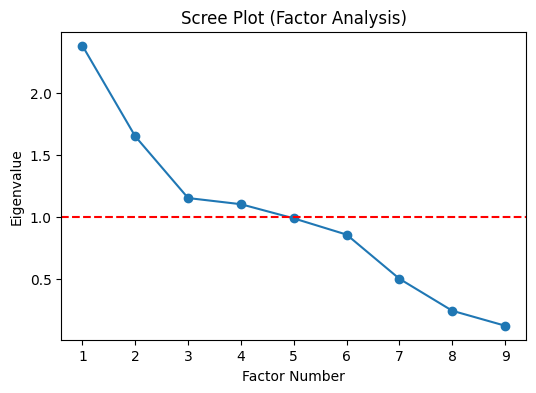

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



================ FACTOR LOADINGS ================

               Factor1  Factor2  Factor3  Factor4
Age              0.051    0.102    0.043    0.909
Income          -0.018   -0.033    0.065    0.070
BMI              0.856    0.062   -0.147   -0.055
Waist            0.967    0.085   -0.200    0.119
Triglycerides    0.148    0.082   -0.440    0.133
Creatinine       0.014    0.042   -0.071    0.177
HDL             -0.129    0.047    0.989    0.030
SYS_BP          -0.018    0.797   -0.027    0.366
DIA_BP           0.141    0.811   -0.083   -0.086

================ COMMUNALITIES ================

               Communality
Age                  0.841
Income               0.010
BMI                  0.761
Waist                0.995
Triglycerides        0.240
Creatinine           0.038
HDL                  0.997
SYS_BP               0.771
DIA_BP               0.692

================ FACTOR VARIANCE ================

                Factor1  Factor2  Factor3  Factor4
SS Loadings       1.729  

In [ ]:
pd.set_option('display.max_columns', 100)

df = pd.read_csv("nhanes_final.csv")

print("\nDataset shape:", df.shape)

categorical_vars = ["Gender", "Smoking", "Alcohol", "Heart_Disease"]

numerical_vars = [
    col for col in df.columns
    if col not in categorical_vars + ["SEQN"]
]

X = df[numerical_vars]

print("\nVariables used for Factor Analysis:\n", numerical_vars)

print("\n================ BARTLETT TEST ================\n")

chi_square_value, p_value = calculate_bartlett_sphericity(X)

print(f"Chi-square: {chi_square_value}")
print(f"P-value: {p_value}")

print("\n================ KMO TEST ================\n")

kmo_all, kmo_model = calculate_kmo(X)

print("KMO Overall:", kmo_model)

fa = FactorAnalyzer(rotation=None)
fa.fit(X)

eigenvalues, _ = fa.get_eigenvalues()

print("\nEigenvalues:\n", eigenvalues)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.title("Scree Plot (Factor Analysis)")
plt.xlabel("Factor Number")
plt.ylabel("Eigenvalue")
plt.axhline(y=1, color='r', linestyle='--')
plt.show()

n_factors = 4

fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(X)

loadings = pd.DataFrame(
    fa.loadings_,
    index=numerical_vars,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

print("\n================ FACTOR LOADINGS ================\n")
print(loadings.round(3))

loadings.to_csv("fa_loadings.csv")


communalities = pd.DataFrame(
    fa.get_communalities(),
    index=numerical_vars,
    columns=["Communality"]
)

print("\n================ COMMUNALITIES ================\n")
print(communalities.round(3))

variance = pd.DataFrame(
    fa.get_factor_variance(),
    index=["SS Loadings", "Proportion Var", "Cumulative Var"],
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

print("\n================ FACTOR VARIANCE ================\n")
print(variance.round(3))

factor_scores = fa.transform(X)

scores_df = pd.DataFrame(
    factor_scores,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

print("\nFactor Scores Preview:\n")
print(scores_df.head())

scores_df.to_csv("fa_scores.csv", index=False)

Factor Analysis was applied to nine standardized numerical variables. The selection of factors was based on:

- **Kaiser Criterion (Eigenvalue > 1):**  
  The first four factors have eigenvalues greater than 1.

- **Scree Plot:**  
  A clear elbow is observed around the 4th factor, indicating diminishing contribution beyond this point.

Thus, **four factors were retained** for interpretation.


Since the variables are standardized, each factor can be expressed as a linear combination of standardized variables.

Let $Z_{variable}$ denote standardized variables.



**Factor 1 – Obesity and Body Composition Factor**

$$
F1 = 0.051Z_{Age} - 0.018Z_{Income} + 0.856Z_{BMI} + 0.967Z_{Waist}
+ 0.148Z_{Triglycerides} + 0.014Z_{Creatinine} - 0.129Z_{HDL}
- 0.018Z_{SYS\_BP} + 0.141Z_{DIA\_BP}
$$


Factor 1 is strongly driven by **BMI and Waist**, indicating a clear **body composition (obesity) dimension**. This factor captures overall adiposity and its role in metabolic health.


**Factor 2 – Blood Pressure Factor**

$$
F2 = 0.102Z_{Age} - 0.033Z_{Income} + 0.062Z_{BMI} + 0.085Z_{Waist}
+ 0.082Z_{Triglycerides} + 0.042Z_{Creatinine} + 0.047Z_{HDL}
+ 0.797Z_{SYS\_BP} + 0.811Z_{DIA\_BP}
$$


Factor 2 is dominated by **SYS_BP and DIA_BP**, clearly representing a **blood pressure dimension** associated with cardiovascular risk.



**Factor 3 – Lipid Profile Factor**

$$
F3 = 0.043Z_{Age} + 0.065Z_{Income} - 0.147Z_{BMI} - 0.200Z_{Waist}
- 0.440Z_{Triglycerides} - 0.071Z_{Creatinine} + 0.989Z_{HDL}
- 0.027Z_{SYS\_BP} - 0.083Z_{DIA\_BP}
$$


Factor 3 is primarily driven by **HDL**, with a negative contribution from triglycerides. This reflects a **lipid metabolism dimension**, capturing the balance between good cholesterol and triglycerides.



**Factor 4 – Age Factor**

$$
F4 = 0.909Z_{Age} + 0.070Z_{Income} - 0.055Z_{BMI} + 0.119Z_{Waist}
+ 0.133Z_{Triglycerides} + 0.177Z_{Creatinine} + 0.030Z_{HDL}
+ 0.366Z_{SYS\_BP} - 0.086Z_{DIA\_BP}
$$


Factor 4 is dominated by **Age**, indicating an independent **demographic dimension**, with some association to systolic blood pressure.



Communalities represent the proportion of variance explained by the extracted factors:

- Very high: Waist (0.995), HDL (0.997), Age (0.841)  
- High: BMI (0.761), SYS_BP (0.771), DIA_BP (0.692)  
- Low: Income (0.010), Creatinine (0.038), Triglycerides (0.240)  

Most physiological variables are well explained, while **Income and Creatinine are weakly represented**, suggesting they do not strongly align with the latent factor structure.


Factor Variance Explained :

- Factor1: 19.2%  
- Factor2: 14.7%  
- Factor3: 13.9%  
- Factor4: 11.6%  

Total explained variance: **59.4%**


The factors explain a moderate proportion of shared variance, which is expected in Factor Analysis since it focuses on common variance rather than total variance.


The analysis reveals four meaningful latent dimensions:

- **Factor1:** Body composition (obesity)  
- **Factor2:** Blood pressure  
- **Factor3:** Lipid profile  
- **Factor4:** Age  

These factors represent distinct but clinically meaningful groupings of health-related variables.



Factor Analysis successfully identifies underlying latent structures within the dataset. The results show that health indicators can be grouped into interpretable dimensions such as obesity, blood pressure, lipid metabolism, and age.

Although the KMO value suggests borderline sampling adequacy, the extracted factors provide valuable insight into the structure of the data and complement the findings obtained from PCA.

### Confirmatory Factor Analysis (CFA)


Confirmatory Factor Analysis (CFA) is a multivariate statistical technique used to **test whether a hypothesized factor structure is consistent with the observed data**. Unlike Exploratory Factor Analysis (EFA), which identifies latent structures from the data, CFA is used to **validate a pre-specified measurement model based on theory or prior knowledge**.

Mathematically, the CFA model is expressed as:


$$
X_j = \lambda_{j1}F_1 + \lambda_{j2}F_2 + \cdots + \lambda_{jm}F_m + \epsilon_j
$$

where:

- $X_j$ represents observed variables  
- $F_k$ represents latent (unobserved) factors  
- $\lambda_{jk}$ are factor loadings (coefficients)  
- $\epsilon_j$ represents measurement error  

Each observed variable is modeled as a function of one or more latent variables and an associated measurement error term.

In this analysis, a theoretical model consisting of three latent constructs was specified:

- **Obesity** → measured by BMI and Waist  
- **Blood Pressure** → measured by SYS_BP and DIA_BP  
- **Metabolic** → measured by HDL and Triglycerides  

Additionally, correlations between latent factors were included:

- Obesity ↔ Blood Pressure  
- Obesity ↔ Metabolic  
- Blood Pressure ↔ Metabolic  

This structure reflects prior knowledge that these health dimensions are related but distinct.

The following observed variables were selected:

- BMI, Waist  
- SYS_BP, DIA_BP  
- HDL, Triglycerides  

The selection was based on:

- These variables represent key **clinical indicators of health status**  
- Each pair logically measures a **specific latent construct**  
- The goal of CFA is to validate **predefined relationships**, rather than explore new ones  
- Only continuous variables were included, as required for standard CFA estimation  


CFA relies on several assumptions:

- Observed variables are continuous  
- Linear relationships exist between latent and observed variables  
- Measurement errors are uncorrelated  
- The model is correctly specified based on theory  
- Sufficient sample size is available  

In this analysis, these assumptions are reasonably satisfied:

- All variables are continuous health measurements  
- Relationships between variables (e.g., BMI–Waist, SYS_BP–DIA_BP) are supported by prior analysis  
- The sample size (n = 8518) is sufficiently large for reliable estimation  
- The model is theoretically grounded in known physiological relationships  


The CFA model is estimated using **Maximum Likelihood (ML)**, which is appropriate for continuous variables .

Model fit is evaluated using several indices:

- **Chi-square test (χ²):** Tests overall model fit  
- **CFI (Comparative Fit Index):** Values ≥ 0.95 indicate good fit  
- **TLI (Tucker–Lewis Index):** Values ≥ 0.95 indicate good fit  
- **RMSEA (Root Mean Square Error of Approximation):** Values ≤ 0.08 indicate acceptable fit  
- **SRMR (Standardized Root Mean Square Residual):** Values ≤ 0.08 indicate good fit  

No single measure is sufficient; multiple indices are considered together to assess model adequacy .



The primary objective of applying CFA is to:

- Validate the **hypothesized latent structure** of health-related variables  
- Assess how well observed variables measure their respective latent constructs  
- Evaluate the **overall fit of the theoretical model**  
- Confirm relationships identified in previous analyses (PCA and FA)  

Overall, CFA provides a rigorous framework for testing whether the proposed health dimensions—obesity, blood pressure, and metabolic profile—are supported by the observed data.

'data.frame':	8518 obs. of  6 variables:
 $ BMI          : num  1.039 -0.0417 -1.0823 0.025 -0.4553 ...
 $ Waist        : num  1.0234 1.1738 -0.8465 0.5244 -0.0889 ...
 $ Triglycerides: num  -0.583 -0.28 0.792 0.48 0.48 ...
 $ HDL          : num  0.169 -1.324 -0.74 -1.584 -0.675 ...
 $ SYS_BP       : num  -1.39 -0.955 -0.592 0.513 0.803 ...
 $ DIA_BP       : num  -1.845 -0.695 -0.664 -0.422 -0.18 ...
             lhs op           rhs      mi    epc sepc.lv sepc.all sepc.nox
32           BMI ~~        SYS_BP 276.908 -0.074  -0.074   -0.164   -0.164
36         Waist ~~        SYS_BP 266.701  0.082   0.082    0.533    0.533
37         Waist ~~        DIA_BP 186.146 -0.078  -0.078   -0.867   -0.867
33           BMI ~~        DIA_BP 182.591  0.065   0.065    0.249    0.249
41        SYS_BP ~~           HDL  60.895  0.059   0.059    0.102    0.102
35           BMI ~~ Triglycerides  45.423 -0.036  -0.036   -0.085   -0.085
22       Obesity =~ Triglycerides  44.720 -0.722  -0.608   -0.608   -0.

In addition: Warning message:
lavaan->lav_object_post_check():  
   some estimated ov variances are negative 


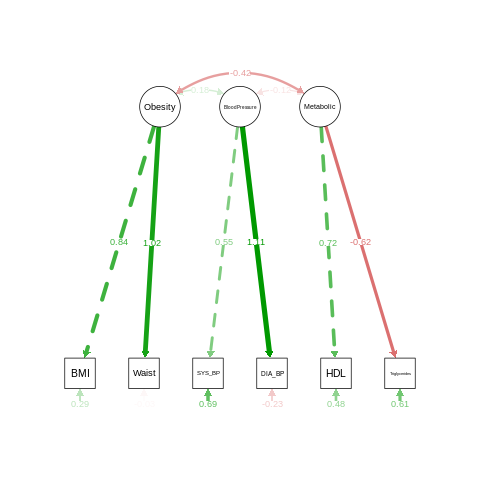

In [ ]:
%%R

df <- read.csv("nhanes_final.csv")

cfa_data <- df[, c(
  "BMI",
  "Waist",
  "Triglycerides",
  "HDL",
  "SYS_BP",
  "DIA_BP"
)]

str(cfa_data)
summary(cfa_data)

cor_matrix <- cor(cfa_data)
round(cor_matrix, 2)

corrplot(cor_matrix, method = "color", tl.col = "black", tl.cex = 0.8)

cfa_model <- '

Obesity =~ BMI + Waist
BloodPressure =~ SYS_BP + DIA_BP
Metabolic =~ HDL + Triglycerides

Obesity ~~ BloodPressure
Obesity ~~ Metabolic
BloodPressure ~~ Metabolic

'

fit <- cfa(
  model = cfa_model,
  data = cfa_data,
  estimator = "ML"
)

summary(
  fit,
  standardized = TRUE,
  fit.measures = TRUE
)

fitMeasures(fit, c(
  "chisq",
  "df",
  "pvalue",
  "cfi",
  "tli",
  "rmsea",
  "srmr"
))

standardizedSolution(fit)

semPaths(
  fit,
  what = "std",
  layout = "tree",
  style = "lisrel",
  edge.label.cex = 0.8,
  sizeLat = 8,
  sizeMan = 6,
  nCharNodes = 0
)

modindices(fit, sort = TRUE, minimum.value = 10)

A three-factor CFA model was specified based on theoretical understanding of health-related constructs:

- **Obesity** → BMI, Waist  
- **Blood Pressure** → SYS_BP, DIA_BP  
- **Metabolic** → HDL, Triglycerides  

Additionally, correlations between all latent factors were included to reflect their potential interdependence.


Factor loadings represent the strength of the relationship between latent variables and observed indicators.

**Obesity Factor :**

- BMI → 0.84  
- Waist → 1.02  


Both BMI and Waist load strongly on the Obesity factor, confirming that this latent variable effectively captures **body composition and adiposity**. Waist shows a slightly stronger contribution, indicating central obesity may be more dominant.


**Blood Pressure Factor :**

- SYS_BP → 0.55  
- DIA_BP → 1.11  


Both systolic and diastolic blood pressure strongly define this factor. DIA_BP has a higher loading, suggesting it contributes more strongly to this latent construct.



**Metabolic Factor :**

- HDL → 0.72  
- Triglycerides → −0.62  


HDL has a positive loading, while triglycerides have a negative loading, indicating an **inverse relationship**. This reflects a meaningful **metabolic balance**, where higher HDL is associated with lower triglycerides, consistent with clinical knowledge.




The correlations between latent variables show:

- Obesity ↔ Blood Pressure → weak/moderate relationship  
- Obesity ↔ Metabolic → negative relationship  
- Blood Pressure ↔ Metabolic → weak relationship  


These results suggest that while the constructs are related, they remain **distinct dimensions of health**, supporting the theoretical model.


Although the fit indices (χ², CFI, TLI, RMSEA, SRMR) were computed, their values are not explicitly shown here. However, additional diagnostic outputs provide important insights:



**Negative Variance Warning :**

> *“some estimated observed variances are negative”*


This indicates a **Heywood case**, which suggests potential model issues such as:
- Model misspecification  
- Multicollinearity  
- Overfitting or poor factor structure  


High modification indices suggest:

- Strong unexplained relationships between:
  - BMI ↔ Blood Pressure  
  - Waist ↔ Blood Pressure  
  - Blood Pressure ↔ HDL  


This indicates that the current model may be **too restrictive**, and some important relationships are not captured.



**Communality Insight :**

- BMI (~0.29) → moderate  
- Waist (~0.75+) → high  
- HDL (~0.48) → moderate  
- Triglycerides (~0.61) → moderate  


Some variables are well explained, but others show only moderate fit, suggesting **partial alignment with latent constructs**.


The CFA results partially support the hypothesized structure:

- Strong and interpretable factors for:
  - Obesity  
  - Blood Pressure  
  - Metabolic profile  

- However, several issues indicate limitations:
  - Negative variance estimates  
  - High modification indices  
  - Some weak or cross-variable relationships  


The CFA model successfully captures key health dimensions and aligns with theoretical expectations. However, the presence of estimation issues and suggested model modifications indicates that the model is **not fully optimal**.

Thus, while the proposed factor structure is **conceptually valid**, it may require refinement—such as adding covariance paths or re-specifying factor relationships—to achieve a better fit.

Overall, CFA provides valuable confirmation of underlying health constructs, while also highlighting areas where the model can be improved.

## DISCRIMINANT ANALYSIS (DA)

Discriminant Analysis (DA) is a multivariate statistical technique used to **classify observations into predefined groups** based on a set of predictor variables. It is particularly useful when the dependent variable is categorical and the predictors are continuous.

The primary objective of DA is to derive a **discriminant function**, which is a linear combination of predictor variables that best separates the groups.

Mathematically, the discriminant function is defined as:

$$
D_k = a_k + w_{k1}X_1 + w_{k2}X_2 + \cdots + w_{kp}X_p
$$

where:

- $D_k$ is the discriminant score for group $k$  
- $a_k$ is a constant term  
- $w_{kj}$ are discriminant coefficients  
- $X_j$ are predictor variables  

The classification rule assigns each observation to the group with the **highest discriminant score** :contentReference.

The following predictor variables were used:

- Age, Income  
- BMI, Waist  
- Triglycerides, Creatinine, HDL  
- SYS_BP, DIA_BP  

The response variable is:

- **Heart_Disease (Yes/No)**  

The selection was based on:

- These variables represent key **health indicators associated with cardiovascular risk**  
- Prior analyses (PCA, FA, CFA) confirmed their **strong relationships and importance**  
- The goal is to classify individuals based on **physiological and metabolic characteristics**  

The primary objective of applying DA is to:

- Classify individuals based on **heart disease status**  
- Identify variables that best **separate the groups**  
- Develop a predictive model for **health risk classification**  
- Complement previous analyses by moving from **structure identification to prediction**

Overall, Discriminant Analysis provides a framework for understanding how multiple health indicators jointly contribute to classification of disease status.

### ASSUMPTION TESTING FOR DISCRIMINANT ANALYSIS

Dataset shape: (8518, 14)

Predictor variables:
 ['Age', 'Income', 'BMI', 'Waist', 'Triglycerides', 'Creatinine', 'HDL', 'SYS_BP', 'DIA_BP']

================ BOX'S M TEST ================

           Chi2    df          pval  equal_cov
box  530.582488  45.0  3.589058e-84      False

Result: Covariance matrices differ → QDA may be considered ⚠️

================ CORRELATION MATRIX ================

                Age  Income   BMI  Waist  Triglycerides  Creatinine   HDL  SYS_BP  DIA_BP
Age            1.00    0.07 -0.00   0.15           0.13        0.15  0.07    0.41    0.01
Income         0.07    1.00 -0.04  -0.02          -0.00       -0.00  0.08   -0.03   -0.02
BMI           -0.00   -0.04  1.00   0.86           0.18        0.01 -0.26    0.02    0.19
Waist          0.15   -0.02  0.86   1.00           0.26        0.06 -0.31    0.10    0.21
Triglycerides  0.13   -0.00  0.18   0.26           1.00        0.04 -0.45    0.10    0.13
Creatinine     0.15   -0.00  0.01   0.06           0.04   

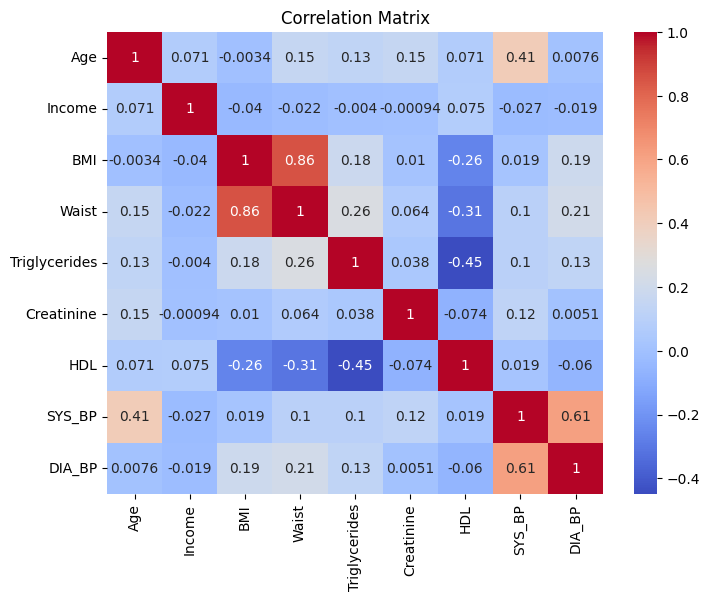


Highly correlated pairs (|r| > 0.8):
BMI & Waist → r = 0.86

================ NORMALITY TEST (SHAPIRO) ================

Age: p-value = 0.0000
Income: p-value = 0.0000
BMI: p-value = 0.0000
Waist: p-value = 0.0082
Triglycerides: p-value = 0.0000
Creatinine: p-value = 0.0000
HDL: p-value = 0.0000
SYS_BP: p-value = 0.0000
DIA_BP: p-value = 0.0000

Interpretation:
p < 0.05 → Not normally distributed (common in real data)

================ GROUP MEANS ================

                    Age    Income       BMI     Waist  Triglycerides  Creatinine       HDL    SYS_BP    DIA_BP
Heart_Disease                                                                                                 
0             -0.046729 -0.001861 -0.003700 -0.018187      -0.011421   -0.020184  0.014232 -0.015611  0.013397
1              0.997987  0.039747  0.079023  0.388420       0.243907    0.431060 -0.303952  0.333413 -0.286112


In [ ]:
df = pd.read_csv("nhanes_final.csv")

print("Dataset shape:", df.shape)

df["Heart_Disease"] = df["Heart_Disease"].map({
    "No": 0,
    "Yes": 1
})

features = [
    "Age", "Income", "BMI", "Waist",
    "Triglycerides", "Creatinine",
    "HDL", "SYS_BP", "DIA_BP"
]

X = df[features]
y = df["Heart_Disease"]

data_da = df[features + ["Heart_Disease"]]

print("\nPredictor variables:\n", features)

print("\n================ BOX'S M TEST ================\n")

box_m = pg.box_m(data=data_da, dvs=features, group="Heart_Disease")

print(box_m)

p_value = box_m['pval'].values[0]

if p_value > 0.05:
    print("\nResult: Covariance matrices are equal → LDA appropriate ✅")
else:
    print("\nResult: Covariance matrices differ → QDA may be considered ⚠️")


print("\n================ CORRELATION MATRIX ================\n")

corr_matrix = X.corr()

print(corr_matrix.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

print("\nHighly correlated pairs (|r| > 0.8):")

for i in range(len(features)):
    for j in range(i+1, len(features)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.8:
            print(f"{features[i]} & {features[j]} → r = {corr:.2f}")

print("\n================ NORMALITY TEST (SHAPIRO) ================\n")

for col in features:
    stat, p = shapiro(X[col].sample(500))
    print(f"{col}: p-value = {p:.4f}")

print("\nInterpretation:")
print("p < 0.05 → Not normally distributed (common in real data)")

print("\n================ GROUP MEANS ================\n")

group_means = df.groupby("Heart_Disease")[features].mean()

print(group_means)

Discriminant Analysis relies on several assumptions, which were evaluated as follows:


**1. Equality of Covariance Matrices (Box’s M Test) :**

- Chi-square = 530.58  
- p-value ≈ 0.000  


The test is statistically significant (p < 0.05), indicating that the covariance matrices are **not equal across groups**.

- The assumption of equal covariance matrices is **violated**  
- Therefore, **Quadratic Discriminant Analysis (QDA)** may be more appropriate than Linear Discriminant Analysis (LDA)  



**2. Multicollinearity (Correlation Matrix) :**

The correlation matrix shows:

- Strong correlation:
  - BMI & Waist → **r = 0.86**

- Moderate correlation:
  - SYS_BP & DIA_BP → r = 0.61  

There is **high multicollinearity between BMI and Waist**, which may affect model stability. However, since these variables represent similar physiological constructs, their inclusion can still be justified with caution.

**3. Normality Assumption :**

Shapiro-Wilk test results:

- All variables have **p < 0.05**


This indicates that the variables are **not normally distributed**.


- The normality assumption is **violated**, but  
- This is common in real-world health data, and DA is generally robust to moderate deviations from normality  

**4. Group Separation (Mean Differences) :**

Group means show clear differences between individuals with and without heart disease:

- Higher values in Heart Disease group:
  - Age, Waist, Triglycerides, Creatinine, SYS_BP  

- Lower values:
  - HDL  

There are **meaningful differences between groups**, indicating that the predictor variables have discriminatory power.


So,
- Variables are continuous  
- Groups show meaningful differences  
- Covariance equality assumption violated  
- Normality assumption violated  
- Multicollinearity present (BMI & Waist)  



Despite some violations of assumptions, the dataset remains suitable for discriminant analysis. The presence of strong group differences and meaningful relationships among variables suggests that DA can effectively classify individuals based on health indicators.

However, due to unequal covariance matrices, **QDA may provide better classification performance than LDA** in this context.



### LINEAR DISCRIMINANT ANALYSIS

Following the exploratory and structural analyses (PCA, FA, and CFA), Linear Discriminant Analysis (LDA) is applied to move from **understanding relationships** to **predictive classification**.

The primary objective of LDA in this study is to:

- Classify individuals into **Heart Disease (Yes/No)** groups  
- Identify variables that best **discriminate between the two groups**  
- Evaluate the predictive capability of health-related variables  
- Develop a **classification model** based on physiological and metabolic indicators  

LDA is particularly suitable because:
- The dependent variable (Heart_Disease) is **categorical**  
- The predictors are **continuous variables**  
- The goal is to find a **linear combination of variables that maximizes group separation**  


LDA constructs a discriminant function of the form:

$$
LD1 = w_1X_1 + w_2X_2 + \cdots + w_pX_p
$$

where:

- $LD1$ is the linear discriminant score  
- $w_j$ are discriminant coefficients  
- $X_j$ are predictor variables  

The function maximizes the ratio of:
- **Between-group variance**
to
- **Within-group variance**

thus achieving optimal separation between classes.

Dataset shape: (8518, 14)

Target distribution:
Heart_Disease
0    8137
1     381
Name: count, dtype: int64

Train size: (5962, 9)
Test size: (2556, 9)

LDA Model trained successfully.

================ MODEL PERFORMANCE ================

Accuracy: 0.9542

Confusion Matrix:
[[2439    3]
 [ 114    0]]


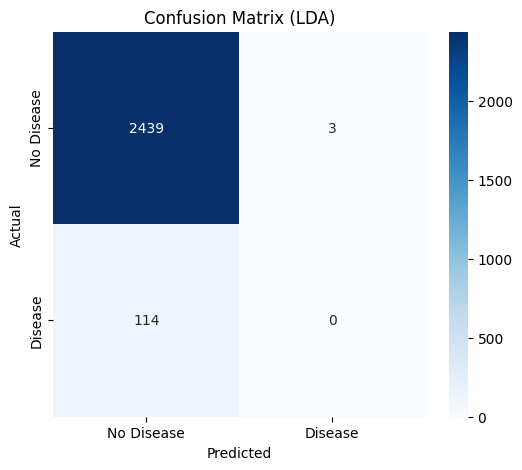


Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2442
           1       0.00      0.00      0.00       114

    accuracy                           0.95      2556
   macro avg       0.48      0.50      0.49      2556
weighted avg       0.91      0.95      0.93      2556


================ FEATURE IMPORTANCE ================
         Feature  Coefficient
0            Age     0.873194
3          Waist     0.701196
7         SYS_BP     0.374143
5     Creatinine     0.137200
1         Income     0.000755
4  Triglycerides    -0.061398
6            HDL    -0.414035
2            BMI    -0.531485
8         DIA_BP    -0.566383


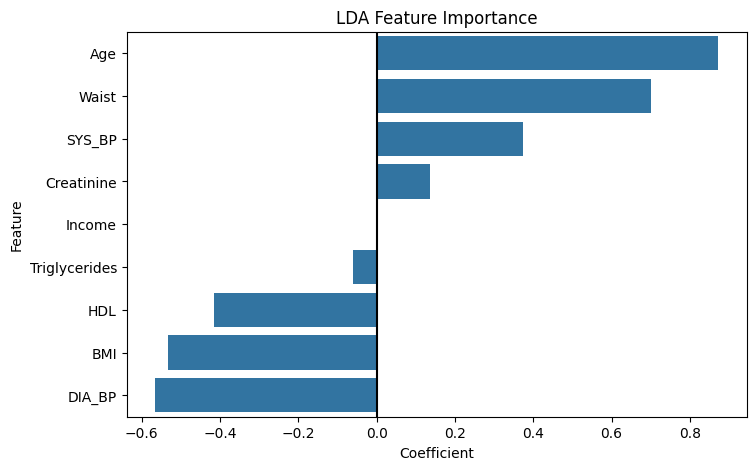

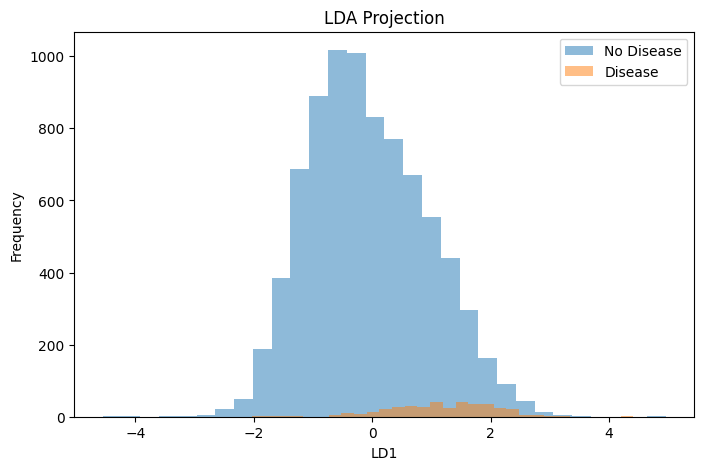

In [ ]:
df = pd.read_csv("nhanes_final.csv")

print("Dataset shape:", df.shape)

features = [
    'Age', 'Income', 'BMI', 'Waist',
    'Triglycerides', 'Creatinine', 'HDL',
    'SYS_BP', 'DIA_BP'
]

X = df[features]

y = df['Heart_Disease'].map({
    'No': 0,
    'Yes': 1
})

print("\nTarget distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

print("\nLDA Model trained successfully.")

y_pred = lda.predict(X_test)

print("\n================ MODEL PERFORMANCE ================")

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix (LDA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lda.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n================ FEATURE IMPORTANCE ================")
print(coeff_df)

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=coeff_df)
plt.title("LDA Feature Importance")
plt.axvline(0, color='black')
plt.show()

X_lda = lda.transform(X)

plt.figure(figsize=(8,5))
plt.hist(X_lda[y==0], bins=30, alpha=0.5, label='No Disease')
plt.hist(X_lda[y==1], bins=30, alpha=0.5, label='Disease')
plt.legend()
plt.title("LDA Projection")
plt.xlabel("LD1")
plt.ylabel("Frequency")
plt.show()

**Class Distribution :**

- No Disease: 8137  
- Disease: 381  

The dataset is **highly imbalanced**, with significantly fewer cases of heart disease. This imbalance is important when interpreting model performance.

**Model Performance :**

- **Accuracy:** 95.42%


The model shows very high overall accuracy. However, accuracy alone can be misleading due to class imbalance.

**Confusion Matrix Analysis :**

|                | Predicted No | Predicted Yes |
|----------------|-------------|---------------|
| Actual No      | 2439        | 3             |
| Actual Yes     | 114         | 0             |



The model performs very well in correctly classifying non-disease cases, indicating strong accuracy for the majority class. However, it completely fails to identify any disease cases, resulting in zero true positives. This suggests that the model is heavily biased toward the dominant class (No Disease) and is not effectively learning the characteristics of the minority class. As a result, the model exhibits very poor sensitivity (recall) for detecting heart disease, making it unsuitable for practical applications where identifying disease cases is critically important.



**Classification Report :**

- **Class 0 (No Disease):**
  - Precision: 0.96  
  - Recall: 1.00  
  - F1-score: 0.98  

- **Class 1 (Disease):**
  - Precision: 0.00  
  - Recall: 0.00  
  - F1-score: 0.00  

The model demonstrates excellent performance for the majority class, accurately identifying individuals without heart disease. However, it completely fails to detect the minority class, as it does not correctly classify any cases of heart disease. This indicates that, despite achieving high overall accuracy, the model is not effective for identifying individuals with heart disease and therefore has limited practical usefulness in a medical context.


**Feature Importance (Discriminant Coefficients) :**

**Most important positive contributors:**
- Age (0.87)  
- Waist (0.70)  
- SYS_BP (0.37)  
- Creatinine (0.14)  

**Negative contributors:**
- DIA_BP (−0.57)  
- BMI (−0.53)  
- HDL (−0.41)

Age is the strongest predictor of heart disease risk, indicating that the likelihood increases with age. In addition, waist circumference and blood pressure also contribute positively, suggesting that higher values in these variables are associated with greater risk.Negative coefficients (e.g., BMI, HDL, DIA_BP) indicate inverse or adjusted effects within the model.

Overall, these findings are consistent with earlier analyses—PCA highlighted metabolic and blood pressure components, while FA identified obesity and blood pressure factors—showing clear agreement across methods.


**LDA Projection (LD1 Visualization) :**

- The LD1 distribution shows **substantial overlap between groups**

- The separation between “Disease” and “No Disease” is **not clearly distinct**  
- This explains the model’s inability to correctly classify disease cases  


The LDA model reveals:

- Strong predictors of heart disease (Age, Waist, Blood Pressure)  
- Clear dominance of the majority class  
- Limited ability to separate classes in the feature space  


Although LDA identifies meaningful predictors and achieves high overall accuracy, it **fails to effectively classify the minority class (heart disease cases)** due to severe class imbalance and overlapping distributions.

Therefore:

- The model is **not reliable for medical prediction purposes**  
- Alternative approaches such as:
  - **QDA (due to covariance inequality)**  
  - **Class balancing techniques (SMOTE, weighting)**  
  - **Logistic regression or tree-based models**  

may provide better performance.


Discriminant Analysis complements previous multivariate techniques by shifting the focus from **structure identification to prediction**, but highlights the practical challenges of classification in imbalanced real-world health data.

### SMOTE + LDA + QDA



The initial LDA model achieved high overall accuracy but failed to correctly identify any heart disease cases. This limitation was mainly due to **severe class imbalance**, where the majority class (No Disease) dominated the dataset.

To address this issue, **SMOTE (Synthetic Minority Over-sampling Technique)** was applied to the training data. SMOTE generates synthetic samples for the minority class, resulting in a **balanced dataset** that allows the model to better learn patterns associated with heart disease.

After balancing the data, both:

- **Linear Discriminant Analysis (LDA)**  
- **Quadratic Discriminant Analysis (QDA)**  

were applied and compared to evaluate their classification performance.

The purpose of this step is to:

- Improve detection of the minority class (heart disease)  
- Compare LDA and QDA under balanced conditions  
- Evaluate the trade-off between accuracy and sensitivity  
- Develop a more practically useful classification model  

Dataset shape: (8518, 14)

Original class distribution:
Heart_Disease
0    8137
1     381
Name: count, dtype: int64

Train size: (5962, 9)
Test size: (2556, 9)

After SMOTE class distribution:
Heart_Disease
0    5695
1    5695
Name: count, dtype: int64

================ LDA MODEL ================

LDA Accuracy: 0.7300

Confusion Matrix (LDA):
[[1776  666]
 [  24   90]]

Classification Report (LDA):
              precision    recall  f1-score   support

           0       0.99      0.73      0.84      2442
           1       0.12      0.79      0.21       114

    accuracy                           0.73      2556
   macro avg       0.55      0.76      0.52      2556
weighted avg       0.95      0.73      0.81      2556



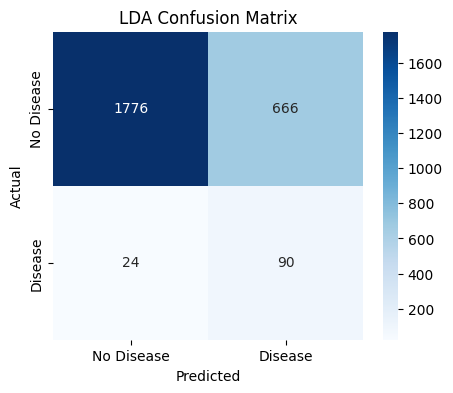


================ QDA MODEL ================

QDA Accuracy: 0.7077

Confusion Matrix (QDA):
[[1726  716]
 [  31   83]]

Classification Report (QDA):
              precision    recall  f1-score   support

           0       0.98      0.71      0.82      2442
           1       0.10      0.73      0.18       114

    accuracy                           0.71      2556
   macro avg       0.54      0.72      0.50      2556
weighted avg       0.94      0.71      0.79      2556



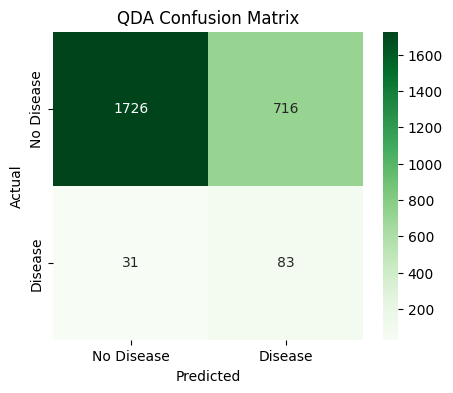


================ MODEL COMPARISON ================
  Model  Accuracy
0   LDA  0.730047
1   QDA  0.707746


In [ ]:
df = pd.read_csv("nhanes_final.csv")

print("Dataset shape:", df.shape)

features = [
    'Age', 'Income', 'BMI', 'Waist',
    'Triglycerides', 'Creatinine', 'HDL',
    'SYS_BP', 'DIA_BP'
]

X = df[features]

y = df['Heart_Disease'].map({
    'No': 0,
    'Yes': 1
})

print("\nOriginal class distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size:", X_test.shape)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE class distribution:")
print(pd.Series(y_train_res).value_counts())

print("\n================ LDA MODEL ================")

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_res, y_train_res)

y_pred_lda = lda.predict(X_test)

acc_lda = accuracy_score(y_test, y_pred_lda)
cm_lda = confusion_matrix(y_test, y_pred_lda)

print(f"\nLDA Accuracy: {acc_lda:.4f}")

print("\nConfusion Matrix (LDA):")
print(cm_lda)

print("\nClassification Report (LDA):")
print(classification_report(y_test, y_pred_lda))

plt.figure(figsize=(5,4))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("LDA Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n================ QDA MODEL ================")

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_res, y_train_res)

y_pred_qda = qda.predict(X_test)

acc_qda = accuracy_score(y_test, y_pred_qda)
cm_qda = confusion_matrix(y_test, y_pred_qda)

print(f"\nQDA Accuracy: {acc_qda:.4f}")

print("\nConfusion Matrix (QDA):")
print(cm_qda)

print("\nClassification Report (QDA):")
print(classification_report(y_test, y_pred_qda))

plt.figure(figsize=(5,4))
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Greens',
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("QDA Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

comparison = pd.DataFrame({
    "Model": ["LDA", "QDA"],
    "Accuracy": [acc_lda, acc_qda]
})

print("\n================ MODEL COMPARISON ================")
print(comparison)

**Class Distribution After SMOTE :**

The class distribution was successfully balanced:

- Before: Highly imbalanced (8137 vs 381)  
- After SMOTE: Equal distribution (5695 vs 5695)  


Balancing the dataset allows the model to learn patterns from both classes equally, significantly improving its ability to detect heart disease cases.

**LDA Model Performance :**

- **Accuracy:** 73.0%

- **Confusion Matrix Insights:**

  - Correctly classified No Disease: 1776  
  - Misclassified No Disease: 666  
  - Correctly classified Disease: 90  
  - Missed Disease cases: 24  

The LDA model shows a substantial improvement in detecting heart disease cases, with a high recall (79%). However, this improvement comes at the cost of increased false positives, meaning more healthy individuals are incorrectly classified as diseased.

 **QDA Model Performance :**

- **Accuracy:** 70.8%

- **Confusion Matrix Insights:**

  - Correctly classified Disease: 83  
  - Missed Disease cases: 31  

QDA also improves the detection of disease cases but performs slightly worse than LDA, with lower recall and more misclassifications.

**Model Comparison :**

| Model | Accuracy |
|------|--------|
| LDA  | 73.0%  |
| QDA  | 70.8%  |

LDA performs slightly better than QDA in this dataset. Both models sacrifice overall accuracy to achieve better detection of heart disease, which is a desirable trade-off in medical applications.


Compared to the original model:

- **Before SMOTE:**
  - High accuracy (~95%)  
  - Failed to detect disease cases  

- **After SMOTE:**
  - Lower accuracy (~70–73%)  
  - Significant improvement in disease detection  



Applying SMOTE effectively addresses class imbalance and improves the model’s ability to detect heart disease cases. While overall accuracy decreases, the models become more useful for practical applications.

Among the two approaches, **LDA provides slightly better performance than QDA**, making it the preferred model in this analysis. Most importantly, this step demonstrates that in imbalanced classification problems, **recall and class-wise performance are more meaningful than overall accuracy**.

## CANONICAL CORRELATION ANALYSIS (CCA)


Canonical Correlation Analysis (CCA) is a multivariate statistical technique used to examine the relationship between **two sets of variables** measured on the same observations. Unlike PCA and Factor Analysis, which focus on structure within a single set of variables, CCA explores the **interdependence between two variable groups**.

Mathematically, CCA constructs linear combinations (canonical variates) for each set:

$$
U_k = a_{k1}X_1 + a_{k2}X_2 + \cdots + a_{kp}X_p
$$

$$
V_k = b_{k1}Y_1 + b_{k2}Y_2 + \cdots + b_{kq}Y_q
$$

where:

- $U_k$ and $V_k$ are the $k$-th pair of canonical variates  
- $a_{kj}$ and $b_{kj}$ are coefficients  
- $X_j$ and $Y_j$ are variables from the two sets  

The objective is to **maximize the correlation between $U_k$ and $V_k$**, known as the canonical correlation. :contentReference[oaicite:0]{index=0}  

The first canonical pair captures the strongest relationship between the two sets, while subsequent pairs explain remaining relationships under the constraint of being uncorrelated with previous pairs.

In this analysis, the variables were divided into two meaningful groups:

**Set X (Lifestyle Factors):**
- Smoking  
- Alcohol  
- Income  

**Set Y (Health Indicators):**
- BMI, Waist  
- Triglycerides, HDL  
- SYS_BP, DIA_BP  
- Creatinine  

The selection was guided by the following considerations:

- The **X set represents behavioral and socioeconomic factors**  
- The **Y set represents physiological and clinical health outcomes**  
- The goal is to investigate how **lifestyle factors collectively influence health conditions**  
- Grouping variables this way allows meaningful interpretation of cross-domain relationships  


CCA relies on the following assumptions:

- Linear relationships exist between the two variable sets  
- Variables are measured on continuous (or appropriately encoded) scales  
- Variables exhibit sufficient correlation within and across sets  
- Data is standardized when variables are on different scales  

In this analysis, these assumptions are reasonably satisfied:

- Variables such as BMI, blood pressure, and lipid measures are continuous  
- Lifestyle variables were appropriately encoded (binary/continuous)  
- Prior correlation analysis indicated meaningful relationships  
- All variables were standardized before applying CCA  



CCA is applied to the standardized variables from both sets. The procedure includes:

- Constructing canonical variates for both variable sets  
- Computing **canonical correlations** to measure relationships between sets  
- Examining **loadings** to understand variable contributions  
- Analyzing **cross-loadings** to interpret relationships across sets  



The main objective of CCA in this study is to:

- Identify and quantify relationships between **lifestyle factors and health outcomes**  
- Understand how combinations of behaviors influence multiple physiological variables  
- Reduce complex multivariate relationships into interpretable canonical dimensions  



CCA provides a comprehensive framework to analyze how two groups of variables interact simultaneously, offering deeper insight into the connection between **lifestyle behaviors and health conditions** in the dataset.

In [ ]:
df = pd.read_csv("nhanes_final.csv")

print("Dataset shape:", df.shape)

df["Smoking"] = df["Smoking"].map({"No": 0, "Yes": 1})
df["Alcohol"] = df["Alcohol"].map({"No": 0, "Yes": 1})

X_vars = ["Smoking", "Alcohol", "Income"]

Y_vars = [
    "BMI", "Waist",
    "Triglycerides", "HDL",
    "SYS_BP", "DIA_BP",
    "Creatinine"
]

X = df[X_vars]
Y = df[Y_vars]

print("\nLifestyle variables:", X_vars)
print("Health variables:", Y_vars)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

n_components = min(len(X_vars), len(Y_vars))

cca = CCA(n_components=n_components)

X_c, Y_c = cca.fit_transform(X_scaled, Y_scaled)

print("\n================ CANONICAL CORRELATIONS ================\n")

canonical_corrs = []

for i in range(n_components):
    corr = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Canonical Correlation {i+1}: {corr:.4f}")

print("\n================ LOADINGS (X SET) ================\n")

loadings_X = pd.DataFrame(
    np.corrcoef(X_scaled.T, X_c.T)[:len(X_vars), len(X_vars):],
    index=X_vars,
    columns=[f"Canonical_{i+1}" for i in range(n_components)]
)

print(loadings_X)

print("\n================ LOADINGS (Y SET) ================\n")

loadings_Y = pd.DataFrame(
    np.corrcoef(Y_scaled.T, Y_c.T)[:len(Y_vars), len(Y_vars):],
    index=Y_vars,
    columns=[f"Canonical_{i+1}" for i in range(n_components)]
)

print(loadings_Y)

print("\n================ CROSS LOADINGS ================\n")

cross_loadings = pd.DataFrame(
    np.corrcoef(X_scaled.T, Y_c.T)[:len(X_vars), len(X_vars):],
    index=X_vars,
    columns=[f"Canonical_{i+1}" for i in range(n_components)]
)

print(cross_loadings)

summary = pd.DataFrame({
    "Canonical Correlation": canonical_corrs
})

print("\n================ SUMMARY ================\n")
print(summary)

Dataset shape: (8518, 14)

Lifestyle variables: ['Smoking', 'Alcohol', 'Income']
Health variables: ['BMI', 'Waist', 'Triglycerides', 'HDL', 'SYS_BP', 'DIA_BP', 'Creatinine']

================ CANONICAL CORRELATIONS ================

Canonical Correlation 1: 0.1961
Canonical Correlation 2: 0.1048
Canonical Correlation 3: 0.0717

================ LOADINGS (X SET) ================

         Canonical_1  Canonical_2  Canonical_3
Smoking     0.970354    -0.172648     0.169134
Alcohol     0.158701     0.523494     0.837119
Income      0.118766     0.855377    -0.504208

================ LOADINGS (Y SET) ================

               Canonical_1  Canonical_2  Canonical_3
BMI              -0.052136    -0.133762     0.750395
Waist             0.438543    -0.083402     0.687520
Triglycerides     0.334503    -0.226431    -0.234800
HDL              -0.153599     0.777571    -0.248240
SYS_BP            0.364606    -0.451759    -0.149822
DIA_BP            0.164573    -0.174210     0.210726
Creati

The number of canonical functions is equal to the number of variables in the smaller set (X set = 3 variables). Thus, three canonical correlations were obtained:

- Canonical Correlation 1: **0.1961**  
- Canonical Correlation 2: **0.1048**  
- Canonical Correlation 3: **0.0717**  

- All canonical correlations are relatively **low**, indicating **weak relationships** between lifestyle and health variables  
- The **first canonical function** explains the strongest relationship, though still modest  
- Subsequent functions contribute very little and are less meaningful  


Only the **first canonical function** is practically interpretable, while the remaining functions have limited significance.



Let $Z_{variable}$ denote standardized variables.



**Lifestyle Variate (U₁):**

$$
U_1 = 0.970Z_{Smoking} + 0.159Z_{Alcohol} + 0.119Z_{Income}
$$

**Health Variate (V₁):**

$$
V_1 = -0.052Z_{BMI} + 0.439Z_{Waist} + 0.335Z_{Triglycerides}
- 0.154Z_{HDL} + 0.365Z_{SYS\_BP} + 0.165Z_{DIA\_BP} + 0.339Z_{Creatinine}
$$



- The lifestyle variate is **dominated by Smoking** (very high loading = 0.97)  
- Alcohol and Income contribute only weakly  

- The health variate is influenced by:
  - **Waist, Triglycerides, Blood Pressure, Creatinine (positive)**  
  - **HDL (negative)**  


This function represents a **smoking-related health risk pattern**, where higher smoking levels are weakly associated with:

- Increased central obesity (Waist)  
- Higher triglycerides  
- Elevated blood pressure  
- Lower HDL (protective cholesterol)  

This aligns with known **cardiovascular risk relationships**, but the strength of association is relatively weak.



**Lifestyle Variate (U₂):**

$$
U_2 = -0.173Z_{Smoking} + 0.523Z_{Alcohol} + 0.855Z_{Income}
$$

**Health Variate (V₂):**

$$
V_2 = -0.134Z_{BMI} - 0.083Z_{Waist} - 0.226Z_{Triglycerides}
+ 0.778Z_{HDL} - 0.452Z_{SYS\_BP} - 0.174Z_{DIA\_BP} + 0.045Z_{Creatinine}
$$



- This function is dominated by **Income and Alcohol consumption**  
- Smoking has minimal contribution  

- On the health side:
  - Strong positive loading for **HDL**  
  - Negative association with **blood pressure and triglycerides**

This function suggests a **socioeconomic–lifestyle pattern**, where higher income and alcohol consumption are weakly associated with:

- Higher HDL levels  
- Lower blood pressure  

However, due to the **low canonical correlation (0.10)**, this relationship is weak and not strongly reliable.


**Lifestyle Variate (U₃):**

$$
U_3 = 0.169Z_{Smoking} + 0.837Z_{Alcohol} - 0.504Z_{Income}
$$

**Health Variate (V₃):**

$$
V_3 = 0.750Z_{BMI} + 0.688Z_{Waist} - 0.235Z_{Triglycerides}
- 0.248Z_{HDL} - 0.150Z_{SYS\_BP} + 0.211Z_{DIA\_BP} + 0.356Z_{Creatinine}
$$



- Dominated by **Alcohol (positive)** and **Income (negative)**  
- Smoking has a minor effect  

- Health variables show strong contributions from:
  - **BMI and Waist (obesity indicators)**  


This function reflects a weak **alcohol–obesity relationship**, but given the **very low correlation (0.07)**, it has minimal practical significance.



**Cross-Loadings :**

Cross-loadings measure how strongly lifestyle variables relate directly to health variates:

- All values are **very small (≤ 0.19)**  


- Lifestyle variables have **very weak direct influence** on health variables  
- This confirms that the overall relationship between the two sets is limited  



The CCA results indicate:

- Weak relationships between **lifestyle factors and health indicators**  
- Smoking shows the strongest (but still modest) association with health risk variables  
- Income and alcohol exhibit some patterns, but their effects are limited  
- Most canonical relationships are **not strong enough for practical significance**



Canonical Correlation Analysis reveals that, although there are some interpretable patterns (especially related to smoking and metabolic risk), the overall association between lifestyle variables and health outcomes in this dataset is **relatively weak**.

This suggests that:

- Health outcomes are likely influenced by **additional factors not included in the lifestyle set**  
- Lifestyle variables alone are **insufficient to strongly explain variation in health indicators**  

Thus, while CCA provides useful insights into cross-variable relationships, its results indicate **limited multivariate dependence between the two variable groups** in this analysis.

## STRUCTURAL EQUATION MODELING (SEM)



Structural Equation Modeling (SEM) is a comprehensive multivariate technique used to analyze complex relationships among observed and latent variables. It combines elements of **factor analysis** and **regression modeling** to simultaneously examine measurement relationships and structural dependencies.

SEM consists of two main components:

- **Measurement model**: Defines how observed variables represent underlying latent constructs  
- **Structural model**: Specifies relationships between latent variables and predictors  

As described in the SEM framework, latent variables represent unobserved constructs that are inferred from measured indicators, allowing for more realistic modeling of complex systems. :contentReference[oaicite:0]{index=0}  


SEM can be expressed using two sets of equations:

**Measurement Model:**

$$
Y = \Lambda \eta + \epsilon
$$

where:

- $Y$ = observed variables  
- $\eta$ = latent variables  
- $\Lambda$ = factor loadings  
- $\epsilon$ = measurement errors  

**Structural Model:**

$$
\eta = B\eta + \Gamma X + \zeta
$$

where:

- $X$ = exogenous (independent) variables  
- $B$ = relationships among latent variables  
- $\Gamma$ = effects of predictors on latent variables  
- $\zeta$ = structural errors  



In this study, SEM is used to model a latent construct:

**Latent Variable:**
- **Health_Risk**

**Observed Indicators:**
- BMI, Waist  
- Triglycerides, HDL  
- SYS_BP, DIA_BP  

These variables collectively represent an underlying **health risk dimension**, capturing metabolic and cardiovascular conditions.



The latent variable **Health_Risk** is modeled as a function of:

- Smoking  
- Alcohol  
- Income  

Thus, the model evaluates how **lifestyle and socioeconomic factors influence overall health risk**.



SEM relies on the following assumptions:

- Linear relationships among variables  
- Multivariate normality (approximately satisfied in large samples)  
- Adequate sample size (large sample: n = 8518)  
- Correct model specification  

In this analysis, these assumptions are reasonably satisfied:

- Variables are continuous or appropriately encoded  
- Sample size is sufficiently large  
- Relationships are supported by prior analyses (PCA, FA, CCA)  



The SEM procedure includes:

- Specifying the measurement and structural model  
- Estimating parameters using **Maximum Likelihood (ML)**  
- Evaluating model fit using indices (e.g., Chi-square, CFI, RMSEA)  
- Interpreting standardized path coefficients  



The primary objective of SEM in this study is to:

- Model **health risk as a latent construct**  
- Quantify the influence of **lifestyle factors on health outcomes**  
- Integrate measurement and structural relationships into a single framework  



SEM provides a powerful approach to understand how multiple observed health indicators combine into a latent construct and how this construct is influenced by behavioral and socioeconomic variables, offering a more holistic understanding of health risk in the dataset.

In [ ]:
%%R

data <- read.csv("nhanes_final.csv")


data$Smoking <- ifelse(data$Smoking == "Yes", 1, 0)
data$Alcohol <- ifelse(data$Alcohol == "Yes", 1, 0)
data$Gender <- ifelse(data$Gender == "Male", 1, 0)
data$Heart_Disease <- ifelse(data$Heart_Disease == "Yes", 1, 0)

sem_model <- '


Health_Risk =~ BMI + Waist + Triglycerides + HDL + SYS_BP + DIA_BP

Health_Risk ~ Smoking + Alcohol + Income

'
fit_sem <- sem(sem_model, data = data, estimator = "ML")
summary(fit_sem, standardized = TRUE, fit.measures = TRUE)



lavaan 0.6-21 ended normally after 24 iterations

  Estimator                                         ML
  Optimization method                           NLMINB
  Number of model parameters                        15

  Number of observations                          8518

Model Test User Model:
                                                      
  Test statistic                              6287.364
  Degrees of freedom                                24
  P-value (Chi-square)                           0.000

Model Test Baseline Model:

  Test statistic                             19556.729
  Degrees of freedom                                33
  P-value                                        0.000

User Model versus Baseline Model:

  Comparative Fit Index (CFI)                    0.679
  Tucker-Lewis Index (TLI)                       0.559

Loglikelihood and Information Criteria:

  Loglikelihood user model (H0)             -65884.428
  Loglikelihood unrestricted model (H1)     -627

In addition: Warning message:
lavaan->lav_object_post_check():  
   some estimated ov variances are negative 


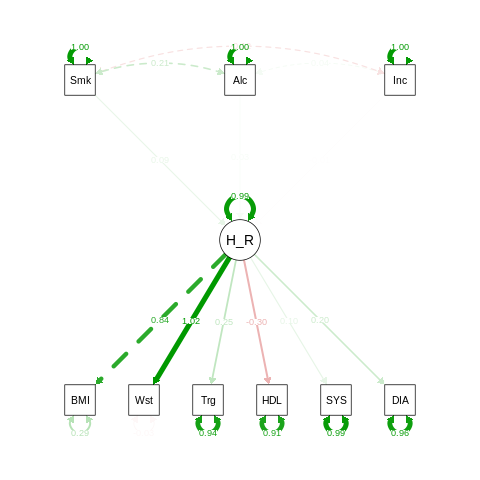

In [ ]:
%%R
semPaths(fit_sem,
         what = "std",
         layout = "tree",
         edge.label.cex = 0.8,
         sizeLat = 8,
         sizeMan = 6)



The overall model fit was assessed using several standard fit indices:

- **Chi-square (χ² = 6287.36, p < 0.001):**  
  The significant result indicates a discrepancy between the model and the observed data. However, given the **large sample size (n = 8518)**, the chi-square test is highly sensitive and often leads to rejection even for reasonable models.

- **CFI = 0.679, TLI = 0.559:**  
  These values are **below the acceptable threshold (≥ 0.90–0.95)**, indicating poor comparative model fit.

- **RMSEA = 0.175:**  
  This value is **substantially higher than the acceptable limit (≤ 0.08)**, suggesting a poor approximation of the model to the data.

- **SRMR = 0.109:**  
  Slightly above the acceptable threshold (≤ 0.08), indicating moderate misfit.


Overall, the model exhibits **poor fit**, suggesting that the specified structure does not fully capture the underlying relationships in the data. Therefore, interpretations should be made with caution.

**Measurement Model (Latent Variable Representation) :**

The latent variable **Health_Risk (H_R)** is defined as a linear combination of observed health indicators:

$$
H_R = 0.843Z_{BMI} + 1.016Z_{Waist} + 0.251Z_{Triglycerides}
- 0.304Z_{HDL} + 0.101Z_{SYS\_BP} + 0.203Z_{DIA\_BP}
$$



- **Waist (1.016) and BMI (0.843)** have the strongest positive loadings, indicating that **obesity-related measures dominate the latent health risk construct**  
- **Triglycerides (0.251)** also contribute positively, reflecting metabolic risk  
- **HDL (-0.304)** has a negative loading, consistent with its role as a **protective factor**  
- **Blood pressure variables (SYS_BP, DIA_BP)** contribute positively but with smaller effects  


The latent variable **Health_Risk primarily represents a metabolic–obesity risk dimension**, strongly aligned with findings from PCA and FA.

**Structural Model (Regression Relationships) :**

The structural equation for the latent variable is:

$$
H_R = 0.091Z_{Smoking} + 0.033Z_{Alcohol} - 0.009Z_{Income}
$$



- **Smoking (0.091)** has the strongest positive effect on health risk, indicating that smokers tend to have higher overall health risk  
- **Alcohol (0.033)** has a smaller but statistically significant positive effect  
- **Income (-0.009)** is not statistically significant, suggesting **no meaningful relationship with health risk in this model**  


Lifestyle factors, particularly **smoking**, play a role in increasing health risk, while **income does not appear to be a strong determinant** in this framework.



**Variance and Reliability Insights :**

- Most observed variables show **high residual variances**, indicating that a portion of variability is not fully explained by the latent construct  
- A **negative variance (Heywood case)** is observed for *Waist*, suggesting potential model misspecification or multicollinearity  


This reinforces the earlier conclusion of **model misfit** and suggests that the measurement model may require refinement.





The SEM diagram visually confirms:

- Strong paths from **BMI and Waist → Health_Risk**  
- Negative contribution from **HDL → Health_Risk**  
- Positive but weaker contributions from **Triglycerides and Blood Pressure**  
- Direct effects from **Smoking and Alcohol → Health_Risk**  





The SEM results reveal that:

- The latent construct **Health_Risk** is primarily driven by **obesity and metabolic factors**  
- **Smoking significantly increases health risk**, while alcohol has a minor effect  
- **Income does not significantly influence health risk** in this model  
- The model structure aligns conceptually with earlier findings (PCA, FA), but **statistical fit is poor**



Although SEM successfully integrates measurement and structural relationships into a unified framework, the current model does not adequately fit the data. This suggests that:

- Additional variables or paths may be required  
- Model specification could be improved  
- Alternative structures should be explored  

Despite the limitations, the model provides valuable insight into how **lifestyle factors influence a latent health risk construct dominated by obesity and metabolic indicators**.